# MOVIELENS大作业

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
# Reading ratings file
ratings = pd.read_csv('./ratings2.csv',  encoding='latin-1', usecols=['user_id', 'movie_id', 'rating', 'timestamp'])

# Reading users file
users = pd.read_csv('./users.csv', 
                    encoding='latin-1', usecols=['user_id', 'gender', 'zipcode', 'age_desc', 'occ_desc'])

# Reading movies file
movies = pd.read_csv('./movies.csv',  encoding='latin-1', usecols=['movie_id', 'title', 'genres'])

# Reading movies info file
movies_info = pd.read_csv('./info.csv',  encoding='latin-1', usecols=['id', 'name', 'genre','intro','directors','starts', 'release_time'])
movies_info.rename(columns ={ 'id':'movie_id', 'starts': 'stars'}, inplace = True)

## 一、传统偏好发现

### 不同职业观影者的偏好分析

In [2]:
# 筛选出观影人次大于300的电影
popular = ratings['movie_id'].value_counts()
popular = popular[popular > 300]
popular = popular.rename('count')
popular = popular.rename_axis('movie_id')
print("Popular:")
display(popular)

Popular:


movie_id
2858    3428
260     2991
1196    2990
1210    2883
480     2672
        ... 
2404     301
1845     301
1012     301
535      301
2363     301
Name: count, Length: 1053, dtype: int64

In [3]:
# 将用户信息与评分信息结合起来
occu_users = pd.merge(users, ratings, on='user_id', how='outer')
occu_users = occu_users[occu_users['movie_id'].isin(popular.index)] # 只保留popular的电影
print('Users\' information with movie ratings:')
display(occu_users.head())

Users' information with movie ratings:


,user_id,gender,zipcode,age_desc,occ_desc,movie_id,rating,timestamp
0,1,F,48067,Under 18,K-12 student,1193,5,978300760
1,1,F,48067,Under 18,K-12 student,661,3,978302109
2,1,F,48067,Under 18,K-12 student,914,3,978301968
3,1,F,48067,Under 18,K-12 student,3408,4,978300275
4,1,F,48067,Under 18,K-12 student,2355,5,978824291


In [4]:
# 统计每种职业的人数
occupations = occu_users['occ_desc'].unique() # 获取所有职业
occupations_counts = users.groupby('occ_desc').count().iloc[:, 0].rename('occupation total number').reset_index()
occupations_counts.columns = ['occupation', 'occupation total number']
print('Each occupation\'s number:')
display(occupations_counts)

Each occupation's number:


,occupation,occupation total number
0,K-12 student,195
1,academic/educator,528
2,artist,267
3,clerical/admin,173
4,college/grad student,759
5,customer service,112
6,doctor/health care,236
7,executive/managerial,679
8,farmer,17
9,homemaker,92


In [5]:
# 将用户-评分信息按照职业划分
users_dict = {}
for occupation in occupations:
    users_dict[occupation] = occu_users[occu_users['occ_desc'] == occupation]
print('Example: doctor/health care:')
display(users_dict[occupation].head())

Example: doctor/health care:


,user_id,gender,zipcode,age_desc,occ_desc,movie_id,rating,timestamp
16197,128,M,37922,56+,doctor/health care,1249,5,977434389
16198,128,M,37922,56+,doctor/health care,1250,5,977434342
16200,128,M,37922,56+,doctor/health care,1282,5,977434389
16201,128,M,37922,56+,doctor/health care,2160,5,977434389
16202,128,M,37922,56+,doctor/health care,2253,4,977434184


In [6]:
# 计算每个职业的观影者对每部电影的平均打分以及每个职业观看每部电影的人数
mean_ratings_dict = {}
for occupation in occupations:
    mean_ratings_dict[occupation] = users_dict[occupation].groupby('movie_id')['rating'].mean().reset_index()
    watcher_count = users_dict[occupation].groupby('movie_id').count()
    watcher_count = watcher_count.iloc[:, 0]
    watcher_count = watcher_count.reset_index()
    watcher_count.columns = ['movie_id', 'number']
    mean_ratings_dict[occupation] = pd.merge(mean_ratings_dict[occupation], watcher_count, on='movie_id', how='outer')

print('Example: doctor/health care:')
display(mean_ratings_dict[occupation].head())

Example: doctor/health care:


,movie_id,rating,number
0,1,4.394737,76
1,2,3.107143,28
2,3,2.714286,21
3,6,4.068966,29
4,7,3.214286,14


In [7]:
# 合并以上数据
frames = []
for occupation, series in mean_ratings_dict.items():
    df = series
    df.columns = ['movie_id', 'rating', 'number']
    df['occupation'] = occupation
    frames.append(df)
all_ratings = pd.concat(frames)
all_ratings = all_ratings.reset_index()
all_ratings = all_ratings.merge(occupations_counts, on='occupation', how='outer')
print('all_ratings:')
all_ratings.head()

all_ratings:


,index,movie_id,rating,number,occupation,occupation total number
0,0,1,3.904255,94,K-12 student,195
1,1,2,3.322581,31,K-12 student,195
2,2,3,3.600000,15,K-12 student,195
3,3,6,4.250000,16,K-12 student,195
4,4,7,3.500000,12,K-12 student,195


In [8]:
# 计算每部电影的平均评分
overall_mean = all_ratings.groupby('movie_id')['rating'].mean().rename('overall_rating')
# 把职业对电影的平均评分合并到all_ratings
all_ratings = all_ratings.merge(overall_mean, on='movie_id', how='outer')
print('all_ratings:')
all_ratings.head()

all_ratings:


,index,movie_id,rating,number,occupation,occupation total number,overall_rating
0,0,1,3.904255,94,K-12 student,195,4.151042
1,0,1,4.229299,157,academic/educator,528,4.151042
2,0,1,4.000000,86,artist,267,4.151042
3,0,1,4.492537,67,clerical/admin,173,4.151042
4,0,1,4.040404,297,college/grad student,759,4.151042


In [9]:
# 计算差异并添加观影总人数到all_ratings
all_ratings['diff_from_avg'] = all_ratings['rating'] - all_ratings['overall_rating']
all_ratings = pd.merge(all_ratings, popular, on='movie_id', how='outer')
print('all_ratings:')
all_ratings.head()

all_ratings:


,index,movie_id,rating,number,occupation,occupation total number,overall_rating,diff_from_avg,count
0,0,1,3.904255,94,K-12 student,195,4.151042,-0.246786,2077
1,0,1,4.229299,157,academic/educator,528,4.151042,0.078258,2077
2,0,1,4.000000,86,artist,267,4.151042,-0.151042,2077
3,0,1,4.492537,67,clerical/admin,173,4.151042,0.341496,2077
4,0,1,4.040404,297,college/grad student,759,4.151042,-0.110638,2077


In [10]:
# 计算评价函数: score = (职业平均评分rating - 平均评分overall_rating) * (该职业的总观影人数number / 观影总人数count + 2 * 该职业的总观影人数number / 该职业总人数occupation total number
w1 = 1
w2 = 2
all_ratings['score'] = all_ratings['diff_from_avg'] * (w1 * all_ratings['number'] / all_ratings['count'] + w2 * all_ratings['number'] / all_ratings['occupation total number'])
all_ratings = all_ratings.set_index('movie_id')
for occupation in occupations:
    score = all_ratings[all_ratings['occupation'] == occupation]
    score = score.drop(['index', 'rating', 'occupation', 'overall_rating'], axis=1)
print('Example: doctor/health care:')
display(score)

Example: doctor/health care:


,number,occupation total number,diff_from_avg,count,score
movie_id,,,,,
1,76,236,0.243695,2077,0.165873
2,28,236,-0.065700,701,-0.018214
3,21,236,-0.306814,478,-0.068082
6,29,236,0.176449,940,0.048808
7,14,236,-0.164260,458,-0.024509
...,...,...,...,...,...
3916,19,236,0.223229,437,0.045649
3927,12,236,0.264032,348,0.035955
3948,30,236,-0.059601,862,-0.017227


In [11]:
# 筛选出每个职业前10名的电影，分别作为该职业偏好的电影
preferences = {}
for occupation in occupations:
    preferences[occupation] = all_ratings[all_ratings['occupation']==occupation].nlargest(10, 'score').reset_index()
    
for occupation in occupations:
    print(occupation, '最偏好的10部电影:')
    preference_detail = pd.merge(preferences[occupation], movies, on='movie_id', how='inner')
    preference_detail = preference_detail.drop(['movie_id', 'index', 'rating', 'occupation', 'overall_rating', 'diff_from_avg', 'count', 'number', 'occupation total number'], axis=1)
    preference_detail['rank'] = preference_detail.index.to_series().apply(lambda x: x+1)
    preference_detail = preference_detail.set_index('rank')
    display(preference_detail)

K-12 student 最偏好的10部电影:


,score,title,genres
rank,,,
1,0.408380,Austin Powers: The Spy Who Shagged Me (1999),Comedy
2,0.362344,Spaceballs (1987),Comedy|Sci-Fi
3,0.358246,Billy Madison (1995),Comedy
4,0.342534,Big Daddy (1999),Comedy
5,0.330416,Austin Powers: International Man of Mystery (1...,Comedy
6,0.314861,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Fantasy|Sci-Fi
7,0.294553,Mission: Impossible 2 (2000),Action|Thriller
8,0.265733,"Me, Myself and Irene (2000)",Comedy
9,0.262665,"Matrix, The (1999)",Action|Sci-Fi|Thriller


self-employed 最偏好的10部电影:


,score,title,genres
rank,,,
1,0.194809,"Terminator, The (1984)",Action|Sci-Fi|Thriller
2,0.190978,Midnight in the Garden of Good and Evil (1997),Comedy|Crime|Drama|Mystery
3,0.177361,Star Trek: The Motion Picture (1979),Action|Adventure|Sci-Fi
4,0.174401,2001: A Space Odyssey (1968),Drama|Mystery|Sci-Fi|Thriller
5,0.163745,Invasion of the Body Snatchers (1956),Horror|Sci-Fi
6,0.162302,"Boat, The (Das Boot) (1981)",Action|Drama|War
7,0.142248,Saving Private Ryan (1998),Action|Drama|War
8,0.141605,Pushing Tin (1999),Comedy
9,0.141104,King Kong (1933),Action|Adventure|Horror


scientist 最偏好的10部电影:


...

,score,title,genres
rank,,,
1,0.282042,Beetlejuice (1988),Comedy|Fantasy
2,0.267308,"Sixth Sense, The (1999)",Thriller
3,0.225170,Predator 2 (1990),Action|Sci-Fi|Thriller
4,0.216875,Gremlins (1984),Comedy|Horror
5,0.215968,Aliens (1986),Action|Sci-Fi|Thriller|War
6,0.215050,"Nutty Professor, The (1996)",Comedy|Fantasy|Romance|Sci-Fi
7,0.214380,"Me, Myself and Irene (2000)",Comedy
8,0.212033,Jaws (1975),Action|Horror
9,0.211524,Animal House (1978),Comedy


retired 最偏好的10部电影:


,score,title,genres
rank,,,
1,0.235410,"African Queen, The (1951)",Action|Adventure|Romance|War
2,0.225964,"Lost World: Jurassic Park, The (1997)",Action|Adventure|Sci-Fi|Thriller
3,0.219104,Gone with the Wind (1939),Drama|Romance|War
4,0.212639,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi
5,0.203488,Erin Brockovich (2000),Drama
6,0.193266,Chariots of Fire (1981),Drama
7,0.173341,2001: A Space Odyssey (1968),Drama|Mystery|Sci-Fi|Thriller
8,0.168977,As Good As It Gets (1997),Comedy|Drama
9,0.164354,Shane (1953),Drama|Western


doctor/health care 最偏好的10部电影:


,score,title,genres
rank,,,
1,0.222818,Mars Attacks! (1996),Action|Comedy|Sci-Fi|War
2,0.212646,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi
3,0.205845,Elizabeth (1998),Drama
4,0.203951,Legends of the Fall (1994),Drama|Romance|War|Western
5,0.185849,Saving Private Ryan (1998),Action|Drama|War
6,0.179628,"River Runs Through It, A (1992)",Drama
7,0.179059,Top Gun (1986),Action|Romance
8,0.175127,Fatal Attraction (1987),Thriller
9,0.169712,"Sixth Sense, The (1999)",Thriller


### 不同类型电影的职业偏好可视化

#### 数据预处理

In [12]:
data = pd.merge(ratings, users, how='outer')
data = pd.merge(data, movies, how='outer')
print('data:')
data.head()

data:


,user_id,movie_id,rating,timestamp,gender,zipcode,age_desc,occ_desc,title,genres
0,1.0,1,5.0,978824268.0,F,48067,Under 18,K-12 student,Toy Story (1995),Animation|Children's|Comedy
1,6.0,1,4.0,978237008.0,F,55117,50-55,homemaker,Toy Story (1995),Animation|Children's|Comedy
2,8.0,1,4.0,978233496.0,M,11413,25-34,programmer,Toy Story (1995),Animation|Children's|Comedy
3,9.0,1,5.0,978225952.0,M,61614,25-34,technician/engineer,Toy Story (1995),Animation|Children's|Comedy
4,10.0,1,5.0,978226474.0,F,95370,35-44,academic/educator,Toy Story (1995),Animation|Children's|Comedy


In [13]:
# 统计不同职业的评分记录数量
data_occupation = {} # 按照不同职业划分数据
occupation_count = {} # 不同职业的评分记录的条数
for occupation in occupations:
    data_occupation[occupation] = data[data.occ_desc == occupation]
    occupation_count[occupation] = data_occupation[occupation].shape[0]
print('每种职业的评分记录数量:')
display(occupation_count)

每种职业的评分记录数量:


{'K-12 student': 23290,
 'self-employed': 46021,
 'scientist': 22951,
 'executive/managerial': 105425,
 'writer': 60397,
 'homemaker': 11345,
 'academic/educator': 85351,
 'programmer': 57214,
 'technician/engineer': 72816,
 'other or not specified': 130499,
 'clerical/admin': 31623,
 'sales/marketing': 49109,
 'college/grad student': 131032,
 'lawyer': 20563,
 'farmer': 2706,
 'unemployed': 14904,
 'artist': 50068,
 'tradesman/craftsman': 12086,
 'customer service': 21850,
 'retired': 13754,
 'doctor/health care': 37205}

#### 将genres进行split操作，构建描述矩阵

In [14]:
# 看看总共有多少个风格
genre_list = []
for i in movies.genres:
    genre = i.split(sep='|')
    genre_list += genre
genre_list = list(set(genre_list))
genre_list

['Horror',
 'War',
 'Thriller',
 'Animation',
 'Action',
 'Drama',
 'Comedy',
 'Crime',
 'Sci-Fi',
 'Fantasy',
 'Documentary',
 'Film-Noir',
 "Children's",
 'Romance',
 'Mystery',
 'Western',
 'Musical',
 'Adventure']

In [15]:
# 统计每个电影的风格
num_movies = movies.shape[0]
for genre in genre_list:
    movies[genre] = 0
for i in movies.index:
    genre = movies.loc[i].genres.split(sep='|')
    for j in genre:
        movies[j][i] = 1
movies.head()

,movie_id,title,genres,Horror,War,Thriller,Animation,Action,Drama,Comedy,...,Sci-Fi,Fantasy,Documentary,Film-Noir,Children's,Romance,Mystery,Western,Musical,Adventure
0,1,Toy Story (1995),Animation|Children's|Comedy,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# 将电影信息、评分信息和用户信息结合
data_2 = pd.merge(ratings, users, how='outer')
data_2 = pd.merge(data_2, movies, how='outer')
print('data2:', data_2.shape)
display(data_2.head())

data2: (1000386, 28)


,user_id,movie_id,rating,timestamp,gender,zipcode,age_desc,occ_desc,title,genres,...,Sci-Fi,Fantasy,Documentary,Film-Noir,Children's,Romance,Mystery,Western,Musical,Adventure
0,1.0,1,5.0,978824268.0,F,48067,Under 18,K-12 student,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0
1,6.0,1,4.0,978237008.0,F,55117,50-55,homemaker,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0
2,8.0,1,4.0,978233496.0,M,11413,25-34,programmer,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0
3,9.0,1,5.0,978225952.0,M,61614,25-34,technician/engineer,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0
4,10.0,1,5.0,978226474.0,F,95370,35-44,academic/educator,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0


In [17]:
# 将data_2按照职业划分
data_2_occupation = {}
for occupation in occupations:
    data_2_occupation[occupation] = data_2[data_2.occ_desc==occupation]
print('Example: doctor/health care:')
display(data_2_occupation[occupation].head())

Example: doctor/health care:


,user_id,movie_id,rating,timestamp,gender,zipcode,age_desc,occ_desc,title,genres,...,Sci-Fi,Fantasy,Documentary,Film-Noir,Children's,Romance,Mystery,Western,Musical,Adventure
84,237.0,1,4.0,976761905.0,M,46835,25-34,doctor/health care,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0
128,385.0,1,5.0,976300183.0,M,68131,25-34,doctor/health care,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0
130,389.0,1,5.0,976298977.0,M,68128,25-34,doctor/health care,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0
178,549.0,1,5.0,976070010.0,M,53217,25-34,doctor/health care,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0
192,590.0,1,5.0,975913115.0,F,98032,35-44,doctor/health care,Toy Story (1995),Animation|Children's|Comedy,...,0,0,0,0,1,0,0,0,0,0


In [18]:
# 初始化一个用于对比职业不同风格差异的表格
column1 = []
for occupation in occupations:
    column1.append(occupation)
    column1.append(occupation)
    column1.append(occupation)
    column1.append(occupation)
column2 = ['mean', 'std', 'count', 'portion'] * len(occupations)
df_2 = pd.DataFrame(np.zeros((len(genre_list), len(column1))), index=genre_list, columns=[column1, column2])
df_2

K-12 student                    self-employed                     \
                    mean  std count portion          mean  std count portion   
Horror               0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
War                  0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Thriller             0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Animation            0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Action               0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Drama                0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Comedy               0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Crime                0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Sci-Fi               0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Fantasy              0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Documentary          0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Film-Noir            0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Children's           0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Romance              0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Mystery              0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Western              0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Musical              0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   
Adventure            0.0  0.0   0.0     0.0           0.0  0.0   0.0     0.0   

            scientist       ... customer service         retired             \
                 mean  std  ...            count portion    mean  std count   
Horror            0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
War               0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Thriller          0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Animation         0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Action            0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Drama             0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Comedy            0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Crime             0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Sci-Fi            0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Fantasy           0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Documentary       0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Film-Noir         0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Children's        0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Romance           0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Mystery           0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Western           0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Musical           0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   
Adventure         0.0  0.0  ...              0.0     0.0     0.0  0.0   0.0   

                    doctor/health care                     
            portion               mean  std count portion  
Horror          0.0                0.0  0.0   0.0     0.0  
War             0.0                0.0  0.0   0.0     0.0  
Thriller        0.0                0.0  0.0   0.0     0.0  
Animation       0.0                0.0  0.0   0.0     0.0  
Action          0.0                0.0  0.0   0.0     0.0  
Drama           0.0                0.0  0.0   0.0     0.0  
Comedy          0.0                0.0  0.0   0.0     0.0  
Crime           0.0                0.0  0.0   0.0     0.0  
Sci-Fi          0.0                0.0  0.0   0.0     0.0  
Fantasy         0.0                0.0  0.0   0.0     0.0  
Documentary     0.0                0.0  0.0   0.0     0.0  
Film-Noir       0.0                0.0  0.0   0.0 

In [19]:
# 收集每个风格的均值，分风格将数据归一化；同时收集每个genre中各个职业的评分数据
for occupation in occupations:
    for genre in genre_list:
        tmp = data_2_occupation[occupation][data_2_occupation[occupation][genre] == 1]
        occupation_mean = tmp['rating'].mean()
        occupation_std = tmp['rating'].std()
        df_2.loc[genre, (occupation, 'mean')] = occupation_mean
        df_2.loc[genre, (occupation, 'std')] = occupation_std
        df_2.loc[genre, (occupation, 'count')] = tmp.shape[0]
        df_2.loc[genre, (occupation, 'portion')] = df_2.loc[genre, (occupation, 'count')] / occupation_count[occupation]
df_2

K-12 student                             self-employed            \
                    mean       std   count   portion          mean       std   
Horror          3.237795  1.352573  1905.0  0.081795      3.266436  1.172127   
War             3.880144  1.174791  1385.0  0.059468      3.926107  1.023735   
Thriller        3.554131  1.215418  4212.0  0.180850      3.571828  1.061087   
Animation       3.463956  1.257100  2164.0  0.092915      3.729696  1.043754   
Action          3.497116  1.214723  6067.0  0.260498      3.510326  1.083843   
Drama           3.782167  1.135164  6000.0  0.257621      3.791983  0.997404   
Comedy          3.497200  1.215747  9465.0  0.406398      3.507570  1.087338   
Crime           3.687085  1.159803  1355.0  0.058179      3.737569  1.007939   
Sci-Fi          3.443795  1.245555  3932.0  0.168828      3.493593  1.103095   
Fantasy         3.298039  1.202021  1275.0  0.054745      3.494278  1.082646   
Documentary     3.581633  1.406344    98.0  0.004208      3.933492  0.997781   
Film-Noir       4.212766  0.923024   235.0  0.010090      4.105583  0.891307   
Children's      3.220679  1.277001  3888.0  0.166939      3.457459  1.110650   
Romance         3.624415  1.146542  2990.0  0.128381      3.612211  1.028827   
Mystery         3.636612  1.236328   732.0  0.031430      3.702542  1.019931   
Western         3.513333  1.163760   300.0  0.012881      3.606457  1.076754   
Musical         3.556738  1.228350  1410.0  0.060541      3.678006  1.069264   
Adventure       3.425658  1.209904  3726.0  0.159983      3.513258  1.088450   

                               scientist            ... customer service  \
               count   portion      mean       std  ...            count   
Horror        3757.0  0.081637  3.336032  1.180146  ...           2390.0   
War           3478.0  0.075574  3.933114  1.037381  ...           1348.0   
Thriller      8945.0  0.194368  3.663175  1.086226  ...           4238.0   
Animation     1613.0  0.035049  3.847805  0.992283  ...            974.0   
Action       11863.0  0.257774  3.559685  1.104162  ...           6493.0   
Drama        16489.0  0.358293  3.836070  1.000104  ...           6369.0   
Comedy       15787.0  0.343039  3.687170  1.054164  ...           7908.0   
Crime         3620.0  0.078660  3.801012  1.025424  ...           1734.0   
Sci-Fi        7024.0  0.152626  3.529564  1.142481  ...           3789.0   
Fantasy       1398.0  0.030377  3.545362  1.062934  ...            934.0   
Documentary    421.0  0.009148  3.987500  0.984071  ...             97.0   
Film-Noir      824.0  0.017905  4.190476  0.867887  ...            329.0   
Children's    2715.0  0.058995  3.592405  1.081688  ...           1597.0   
Romance       6617.0  0.143782  3.689911  1.010342  ...           2649.0   
Mystery       1849.0  0.040177  3.756608  1.050652  ...            718.0   
Western       1146.0  0.024902  3.815029  1.087169  ...            546.0   
Musical       1705.0  0.037048  3.805987  0.998916  ...            888.0   
Adventure     6034.0  0.131114  3.567662  1.090267  ...           3228.0   

                        retired                              \
              portion      mean       std   count   portion   
Horror       0.109382  3.328234  1.165029   719.0  0.052276   
War          0.061693  4.085757  0.944401  1341.0  0.097499   
Thriller     0.193959  3.802019  1.023593  2278.0  0.165625   
Animation    0.044577  3.545732  1.113325   328.0  0.023848   
Action       0.297162  3.679048  1.041760  2773.0  0.201614   
Drama        0.291487  3.949047  0.970738  6084.0  0.442344   
Comedy       0.361922  3.663825  1.063605  4340.0  0.315545   
Crime        0.079359  3.832487  1.042472   985.0  0.071616   
Sci-Fi       0.173410  3.544457  1.071804  1822.0  0.132471   
Fantasy      0.042746  3.678019  1.089923   323.0  0.023484   
Documentary  0.004439  3.970588  0.989608   102.0  0.007416   
Film-Noir    0.015057  4.161058  0.892012   416.0  0.030246   
Children

### 可视化结果展示

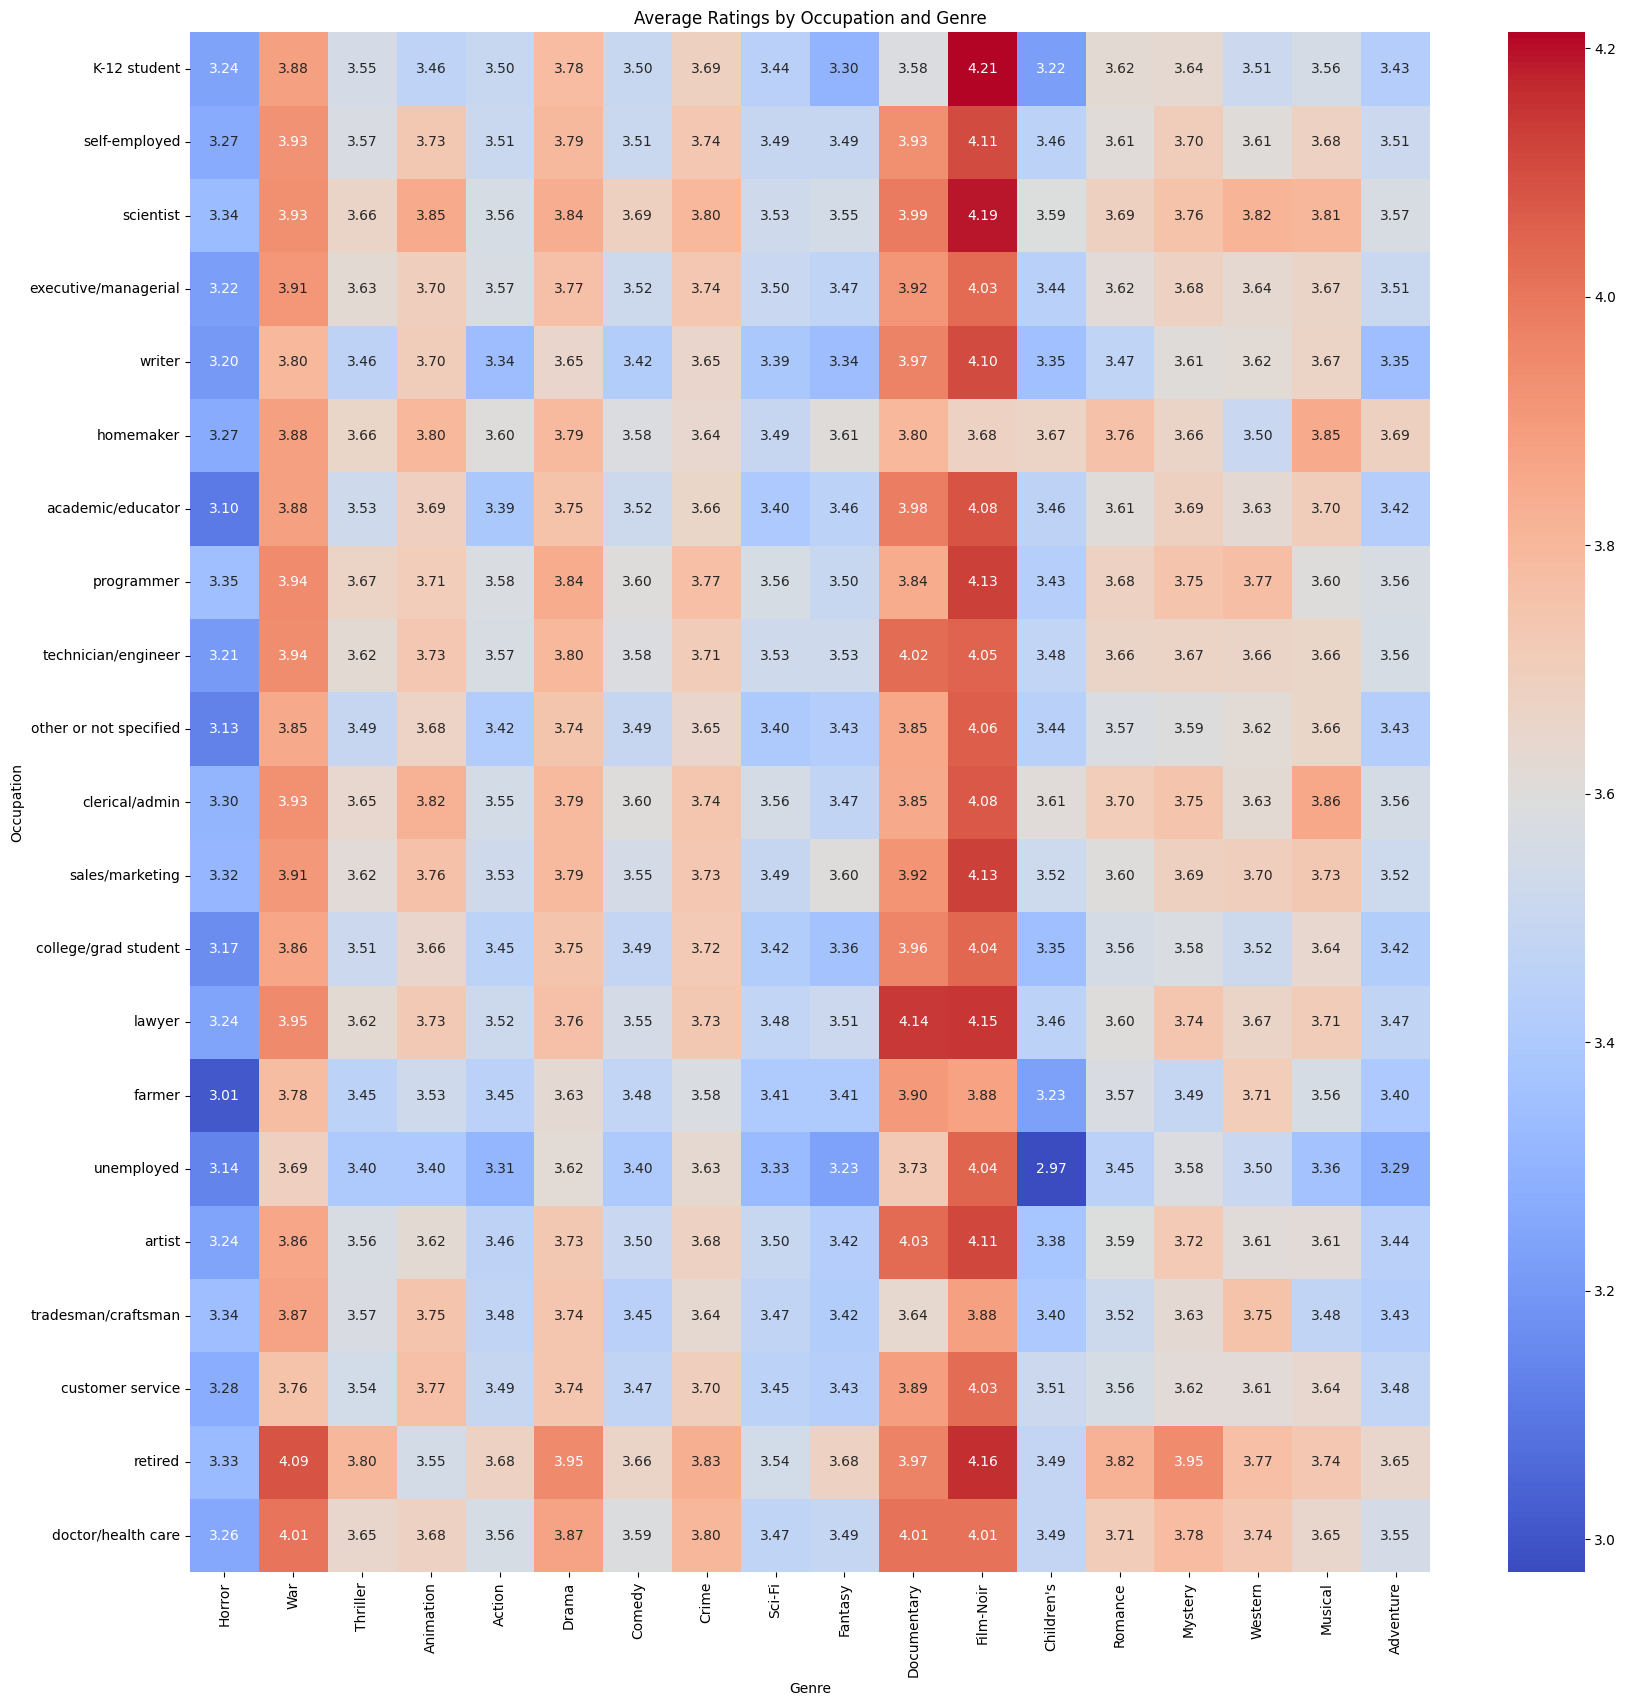

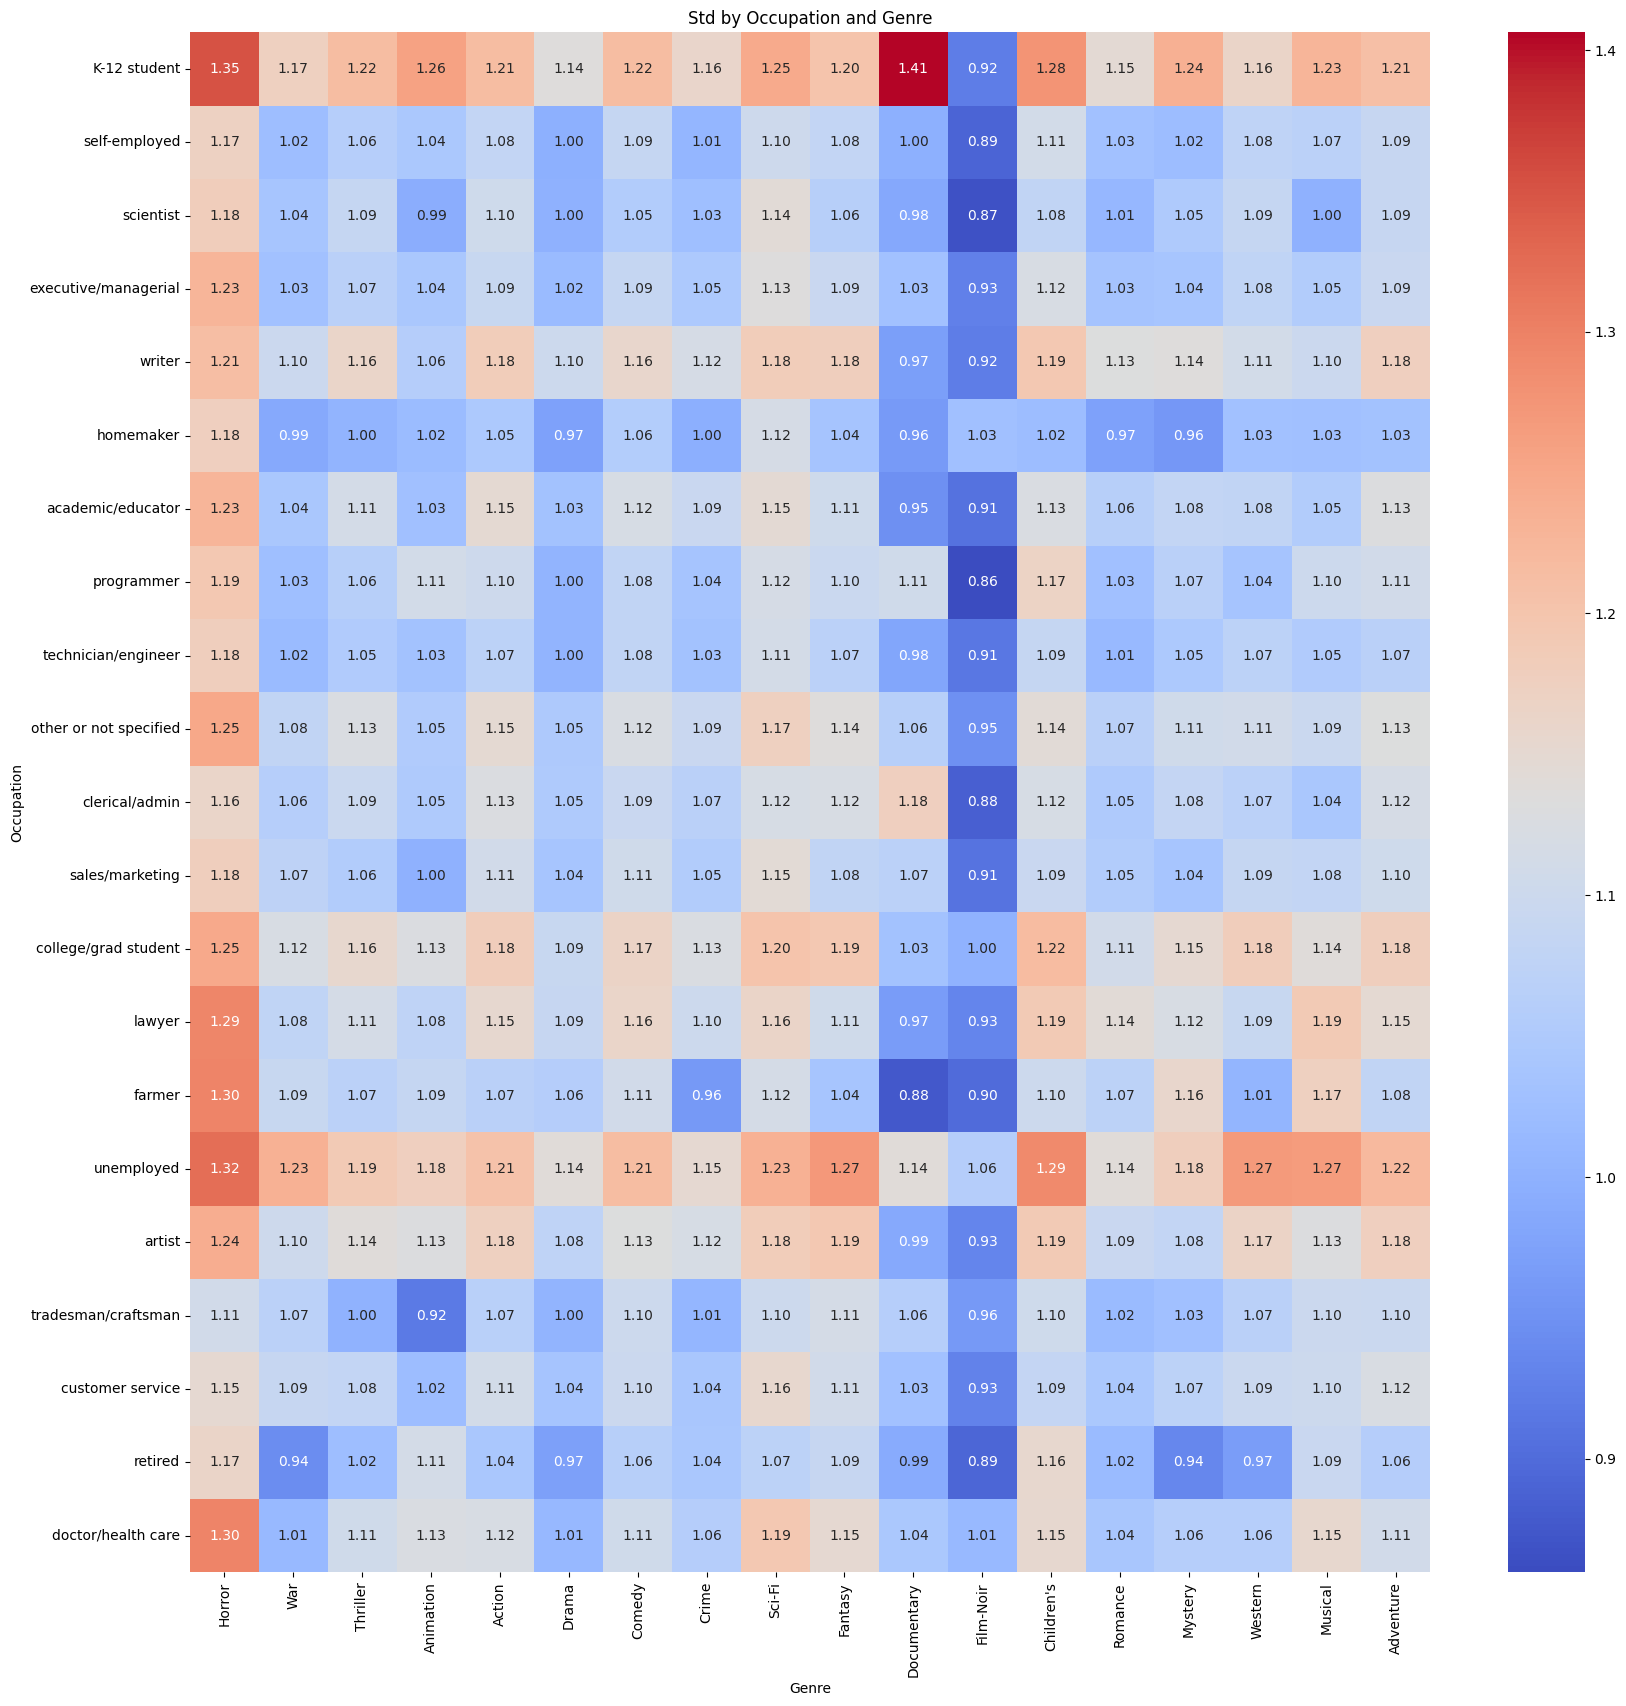

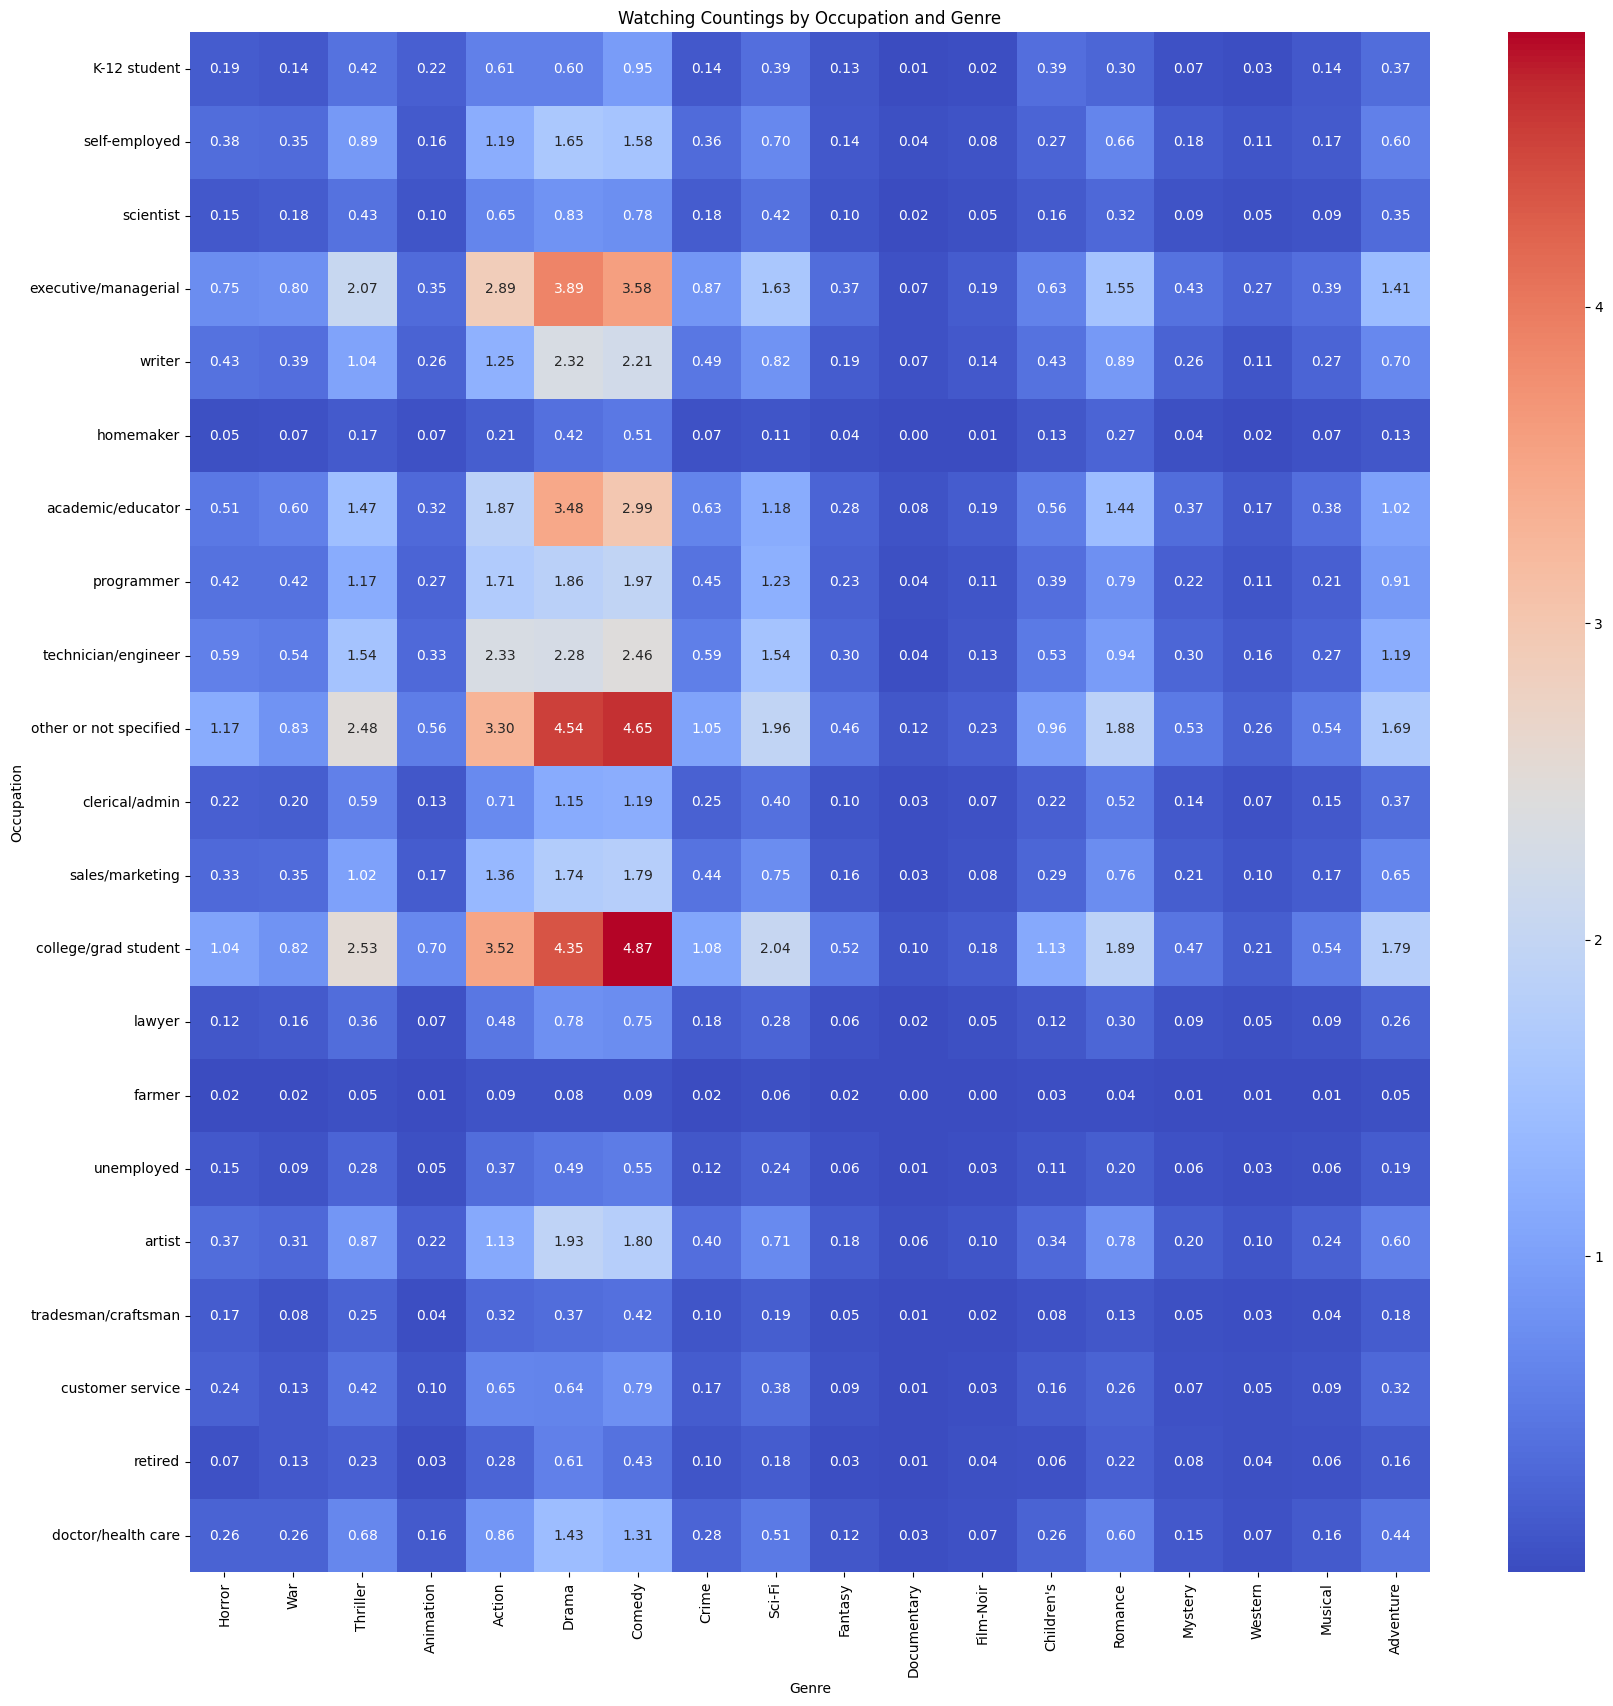

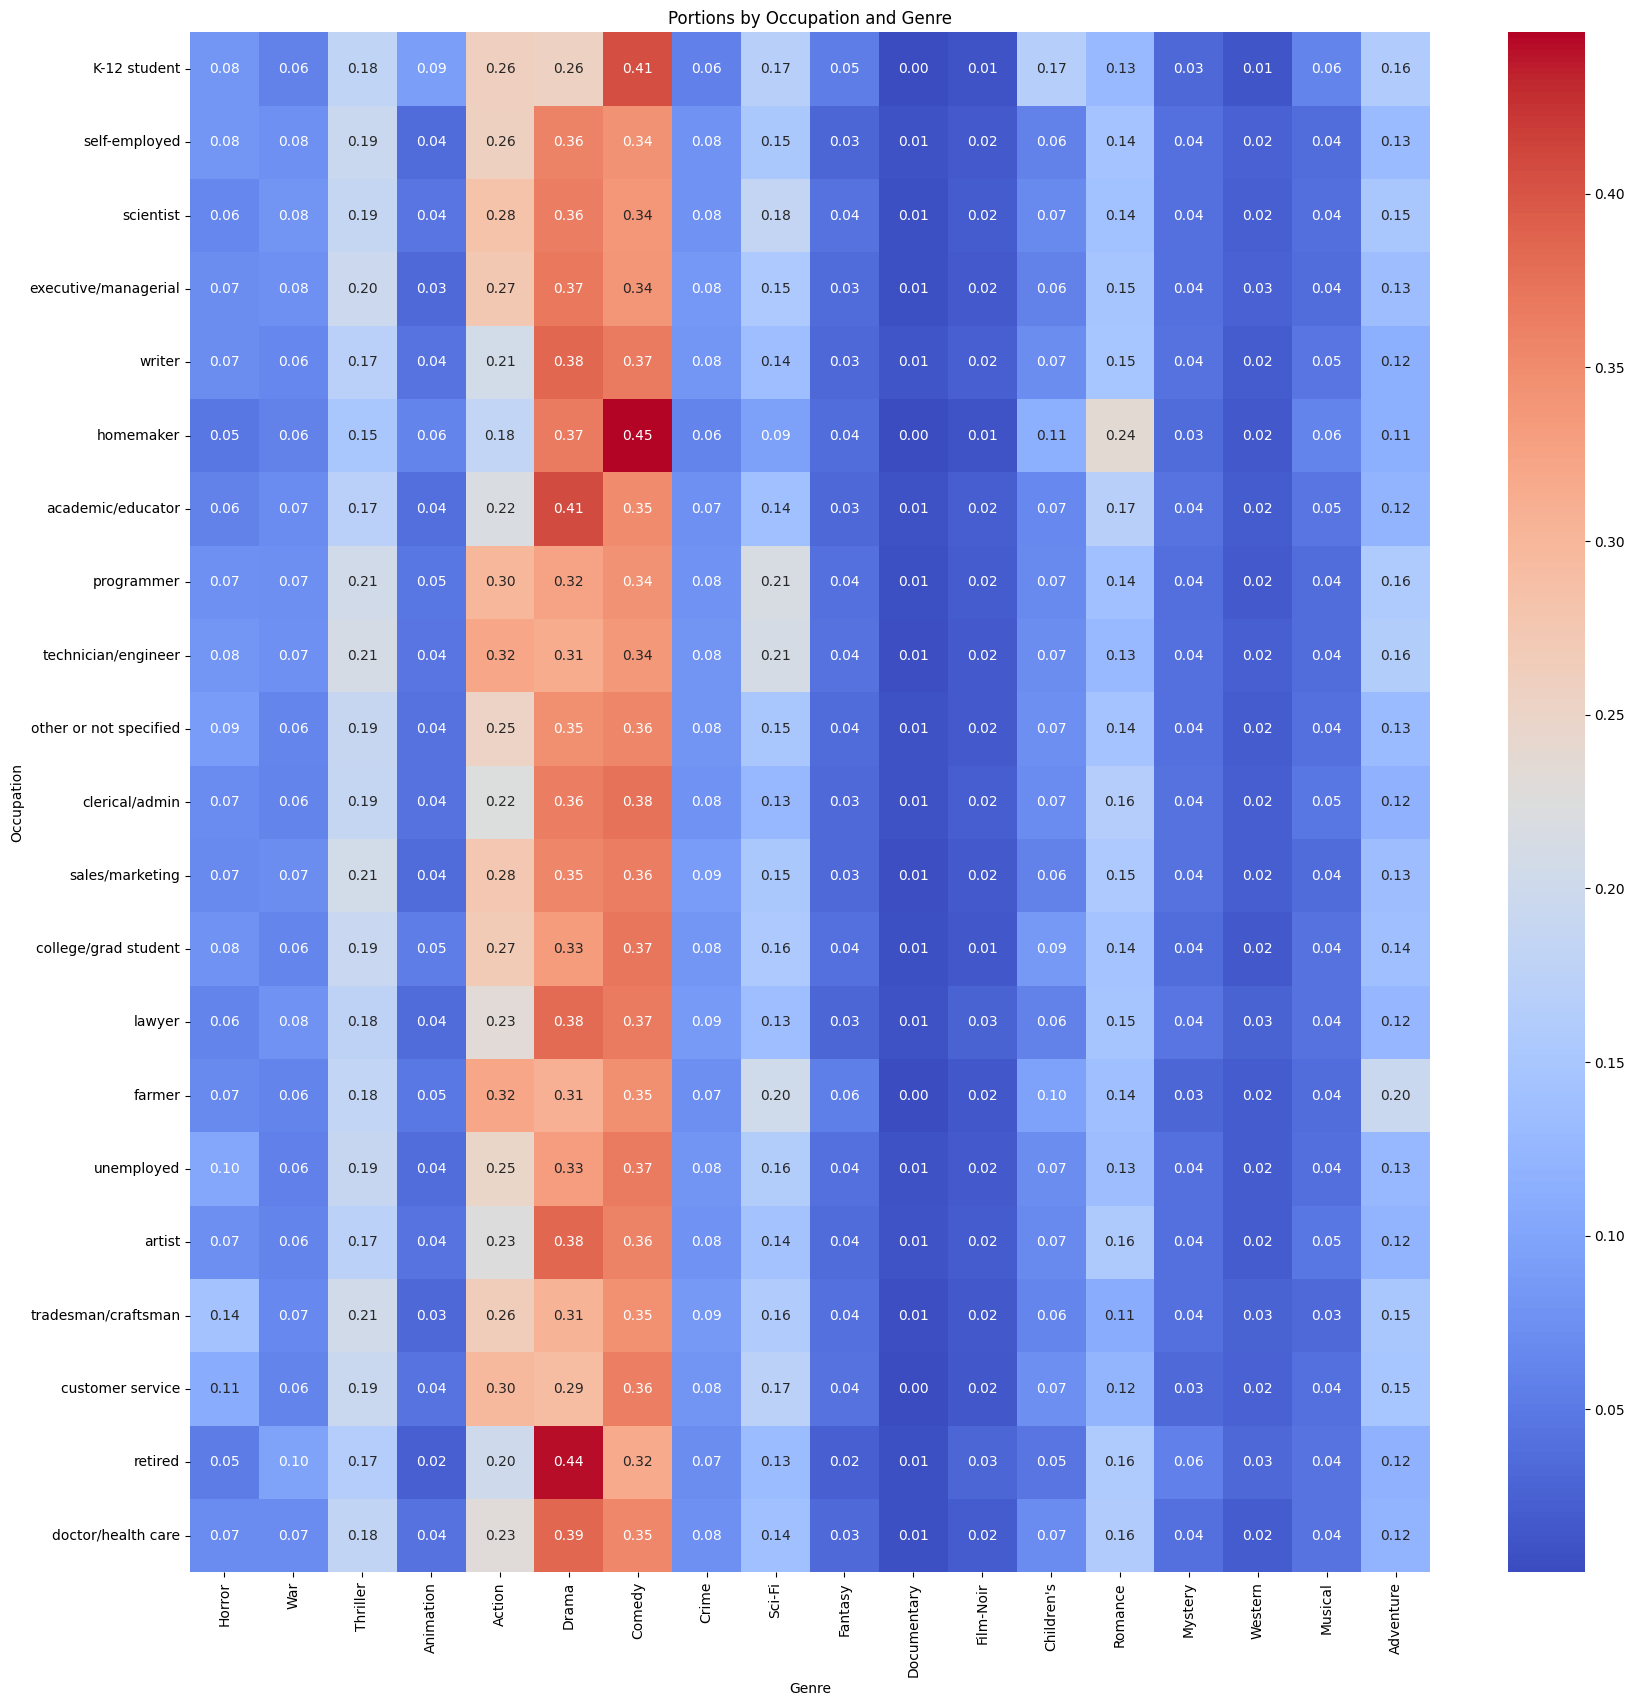

In [20]:
# 用热图的形式呈现数据
import seaborn as sns
import matplotlib.pyplot as plt

# 提取 mean 数据
mean_data = df_2.loc[:, df_2.columns.get_level_values(1) == 'mean'].T

# 使用 seaborn 绘制热图
plt.figure(figsize=(20, 20))
ax = sns.heatmap(mean_data, annot=True, fmt=".2f", cmap='coolwarm')
ax.set_yticklabels(occupations)
plt.title('Average Ratings by Occupation and Genre')
plt.xlabel('Genre')
plt.ylabel('Occupation')
plt.savefig('./figures/0_1_ratings')

# 提取 std 数据
std_data = df_2.loc[:, df_2.columns.get_level_values(1) == 'std'].T

# 使用 seaborn 绘制热图
plt.figure(figsize=(20, 20))
ax = sns.heatmap(std_data, annot=True, fmt=".2f", cmap='coolwarm')
ax.set_yticklabels(occupations)
plt.title('Std by Occupation and Genre')
plt.xlabel('Genre')
plt.ylabel('Occupation')
plt.savefig('./figures/0_2_stds')

# 提取 count 数据
count_data = df_2.loc[:, df_2.columns.get_level_values(1) == 'count'].T

# 使用 seaborn 绘制热图
plt.figure(figsize=(20, 20))
ax = sns.heatmap(count_data / 10000, annot=True, fmt=".2f", cmap='coolwarm')
ax.set_yticklabels(occupations)
plt.title('Watching Countings by Occupation and Genre')
plt.xlabel('Genre')
plt.ylabel('Occupation')
plt.savefig('./figures/0_3_counts')

# 提取 portion 数据
portion_data = df_2.loc[:, df_2.columns.get_level_values(1) == 'portion'].T

# 使用 seaborn 绘制热图
plt.figure(figsize=(20, 20))
ax = sns.heatmap(portion_data, annot=True, fmt=".2f", cmap='coolwarm')
ax.set_yticklabels(occupations)
plt.title('Portions by Occupation and Genre')
plt.xlabel('Genre')
plt.ylabel('Occupation')
plt.savefig('./figures/0_4_portions')


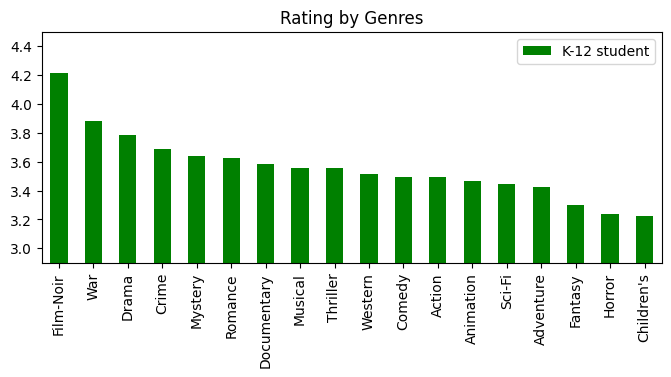

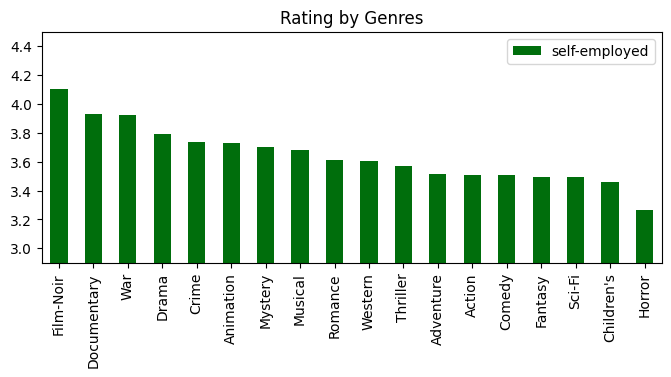

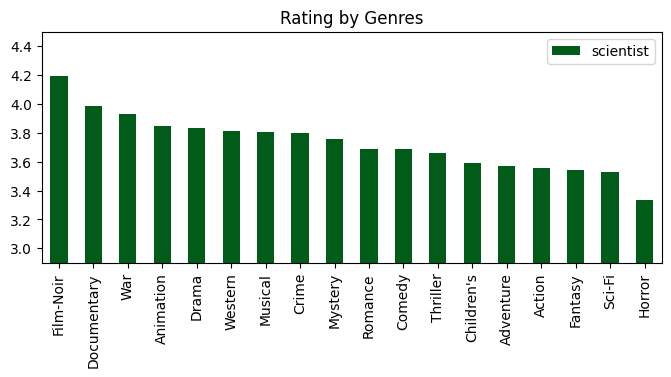

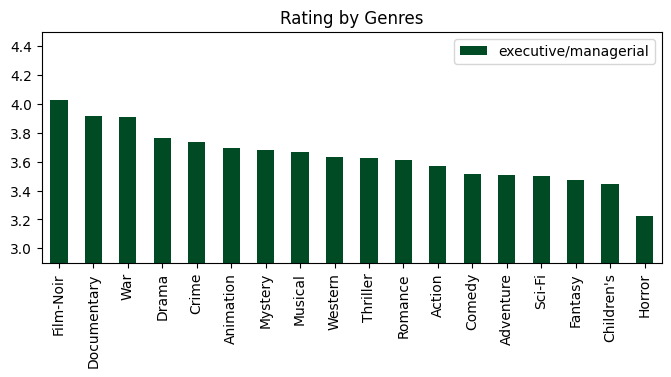

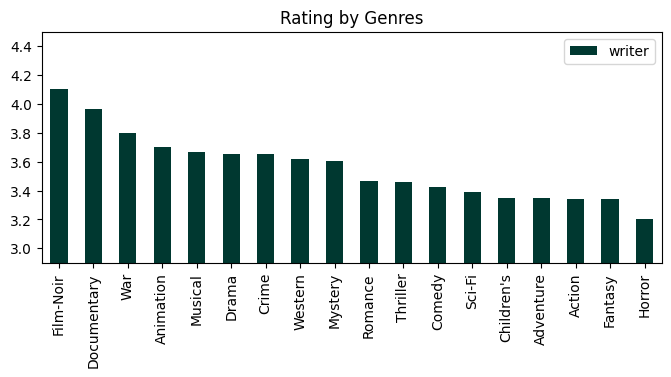

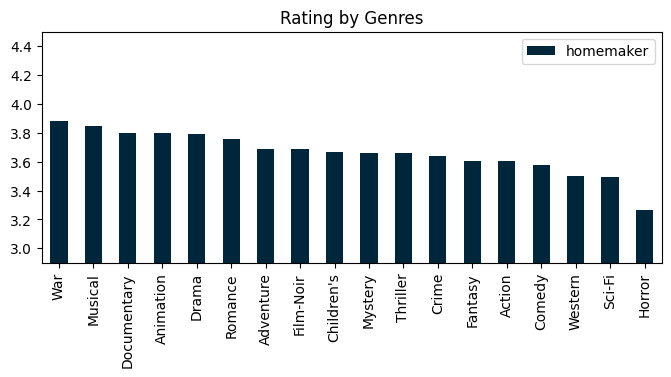

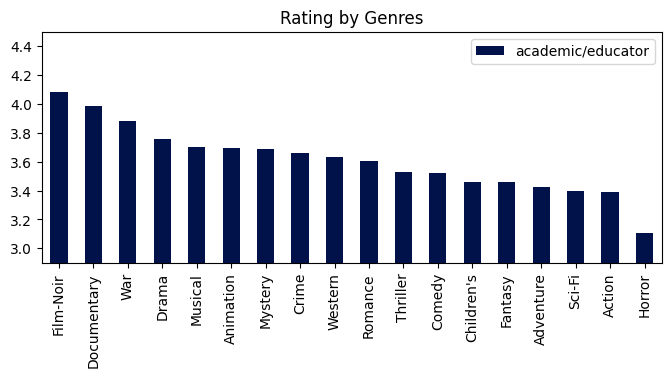

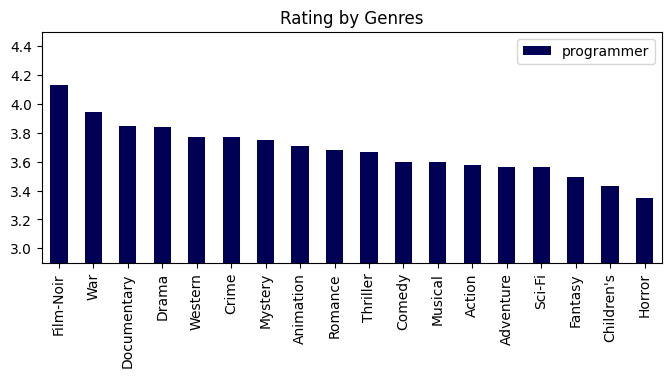

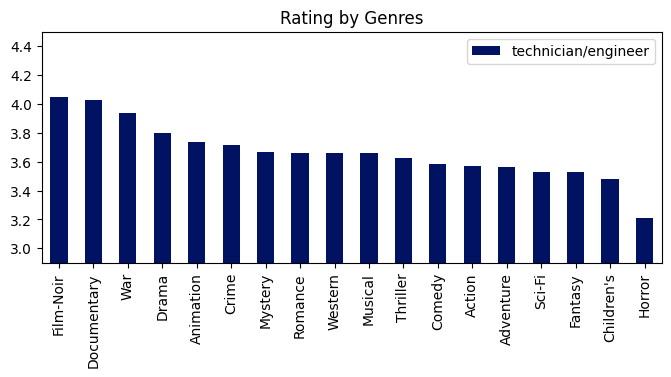

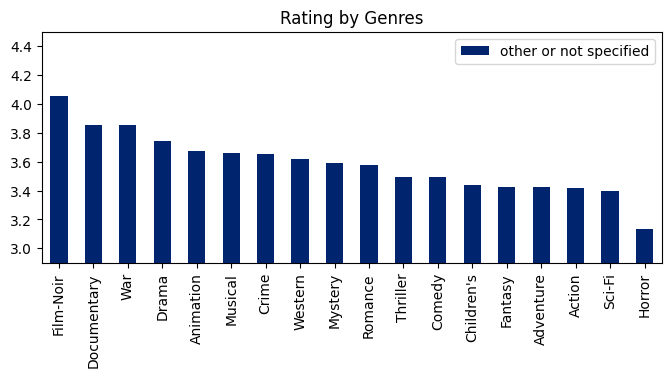

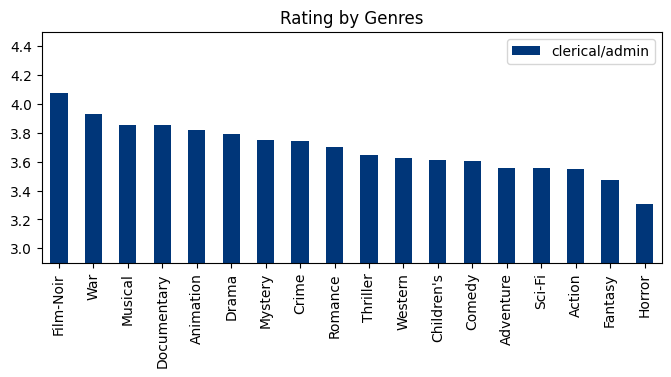

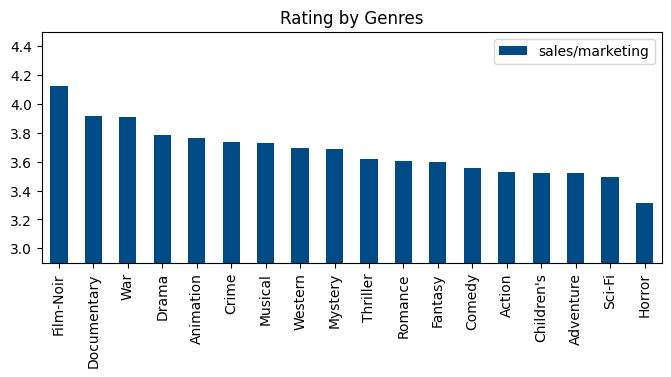

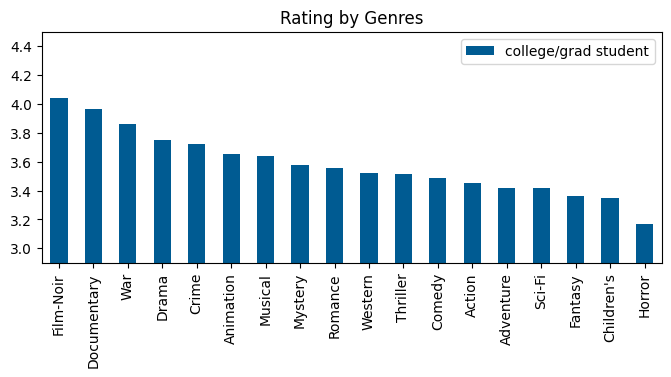

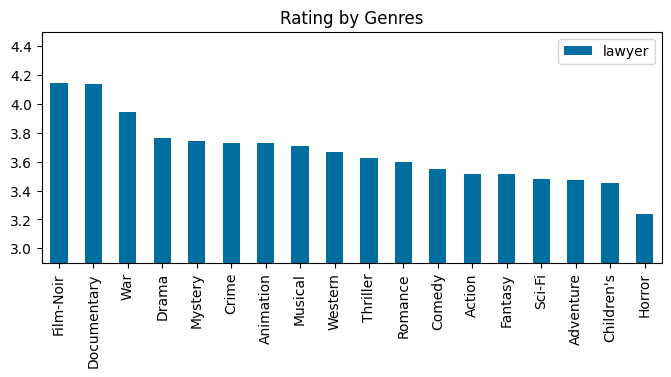

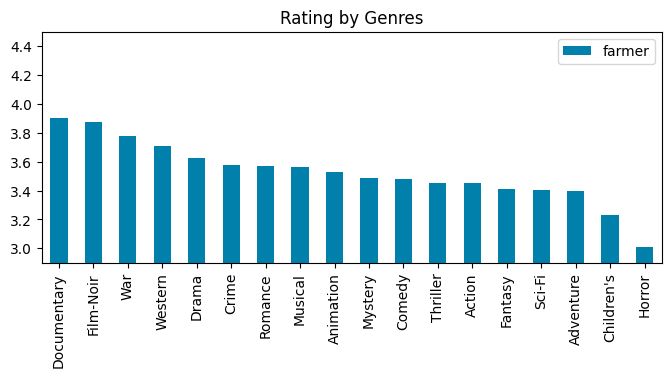

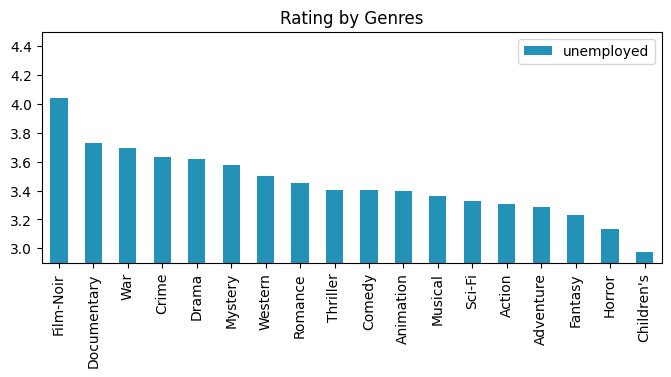

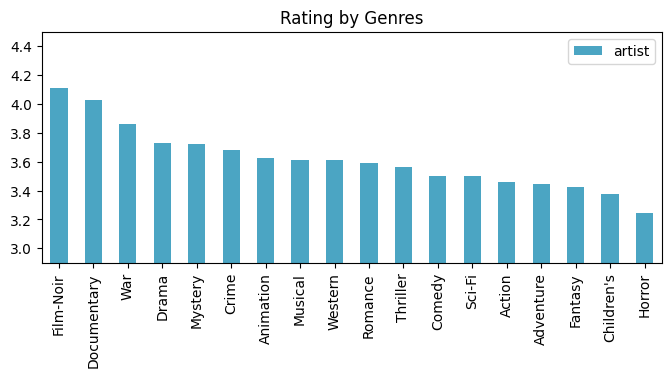

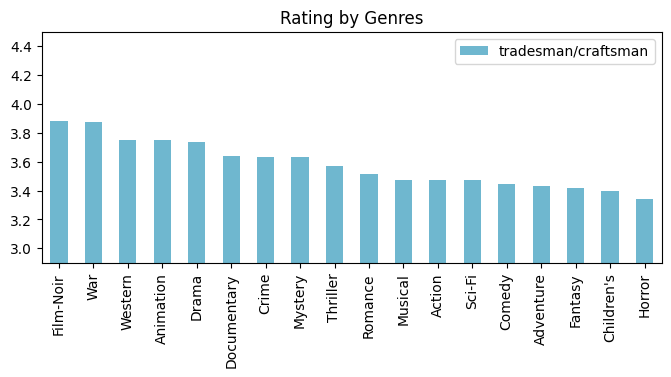

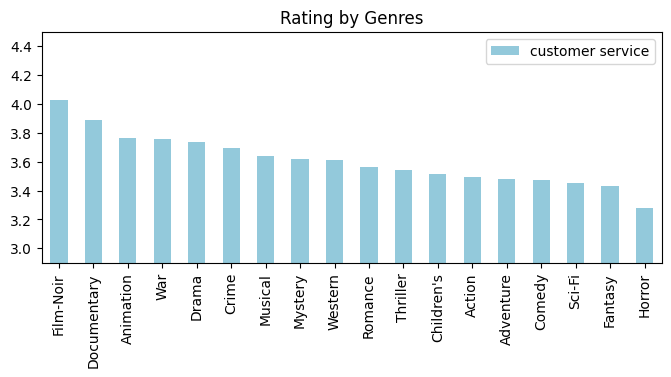

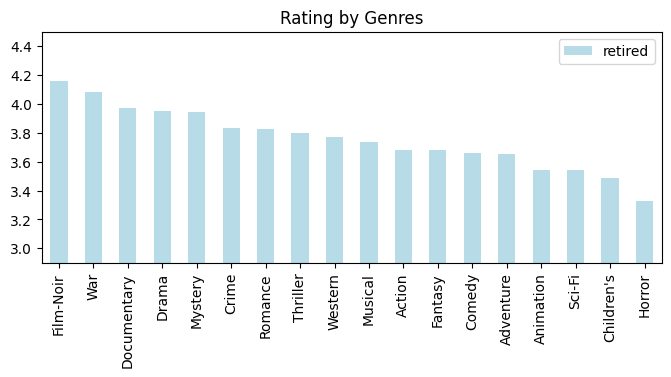

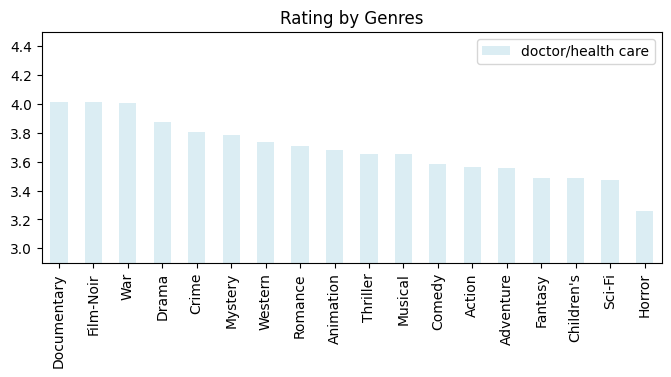

In [21]:
# 将每种职业对每类电影的平均评分从大到小排序后展示
cmap = plt.get_cmap('ocean')
colors = [cmap(i/21) for i in range(len(occupations))]
cnt = 1
for occupation, color in zip(occupations, colors):
    tmp = df_2.sort_values(by=(occupation, 'mean'), inplace=False, ascending=False)
    tmp.plot.bar(y=(occupation, 'mean'),figsize=(8, 3),color=color)
    plt.title('Rating by Genres')
    plt.legend([occupation])
    plt.ylim(2.9, 4.5)
    savefig_title = f"./figures/1_{cnt}_ratings by genres.png"
    plt.savefig(savefig_title)
    cnt += 1

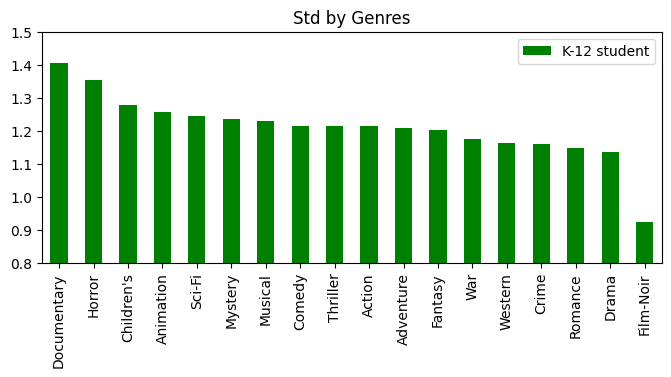

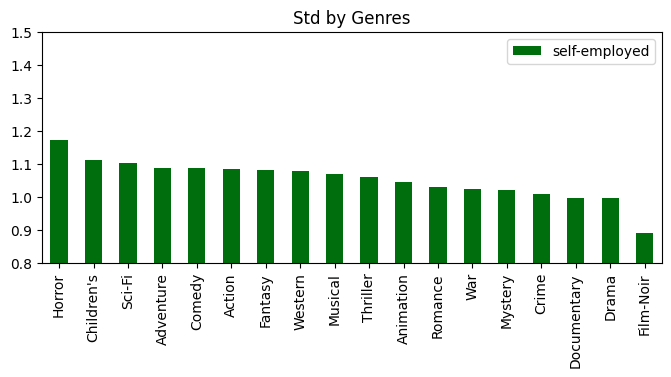

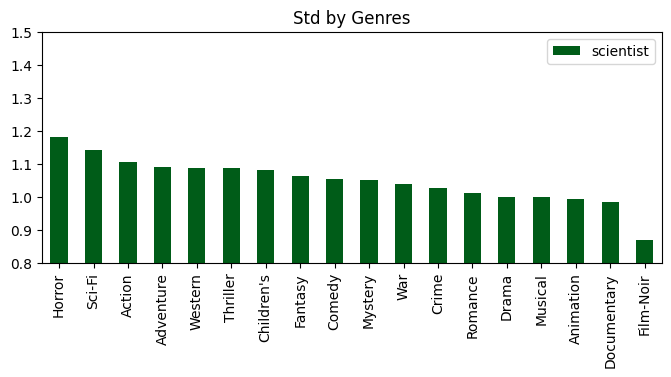

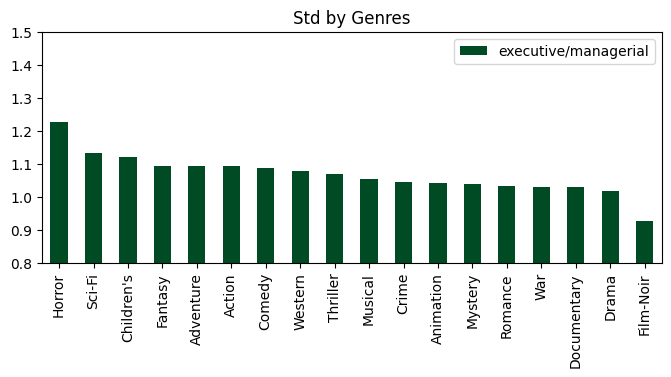

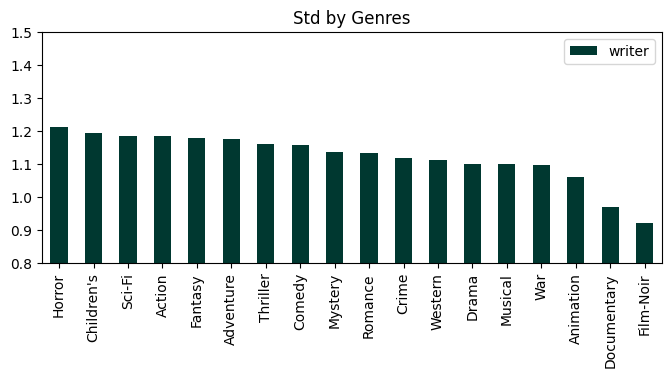

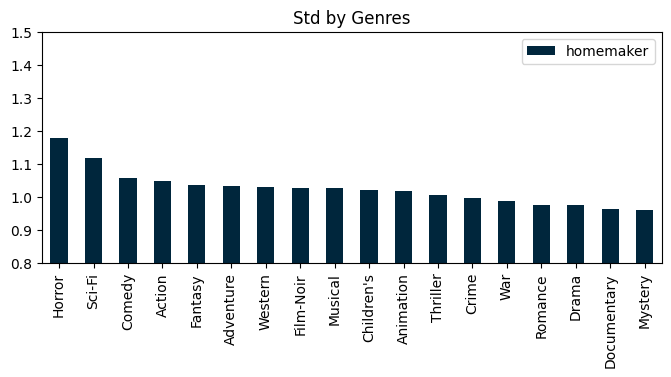

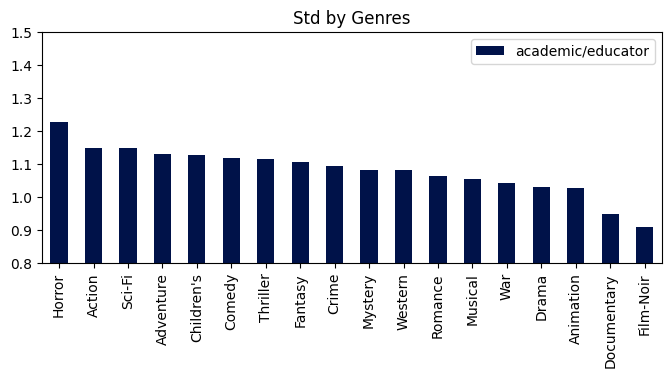

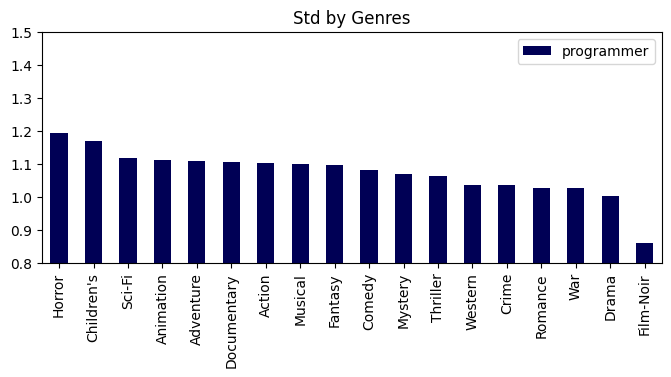

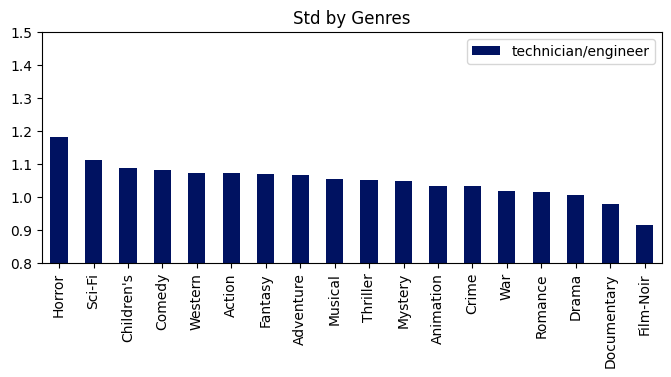

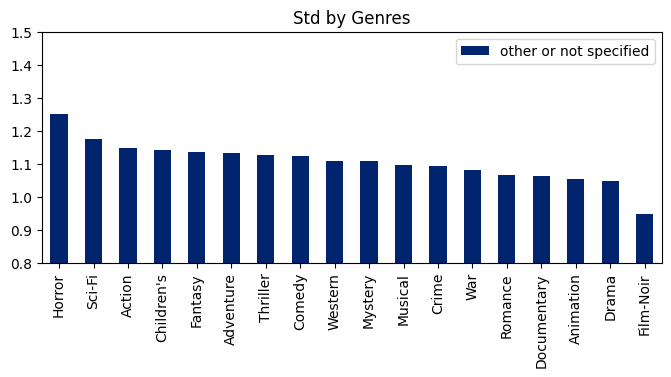

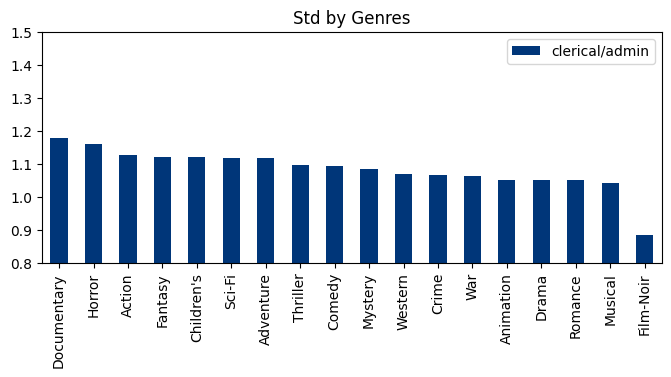

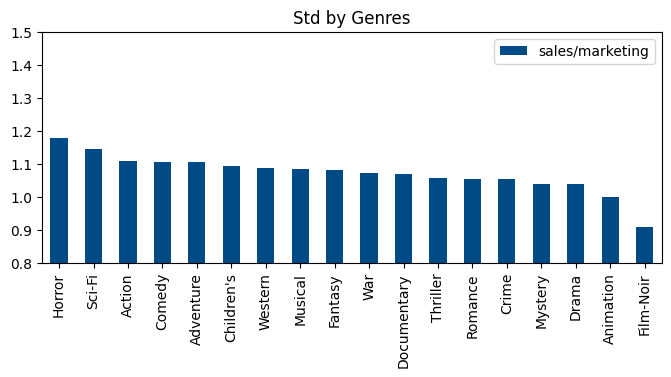

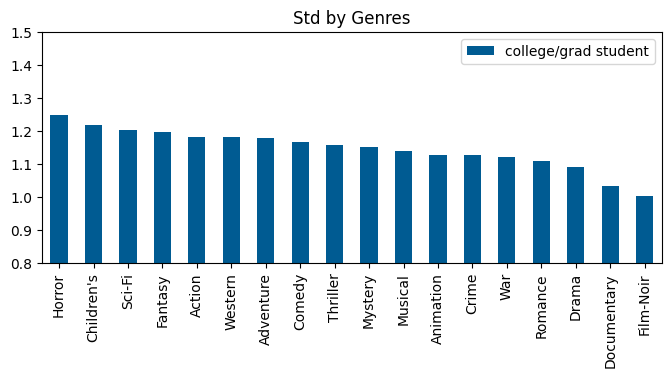

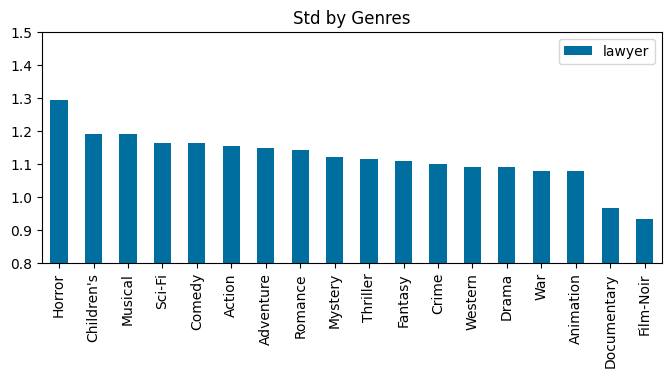

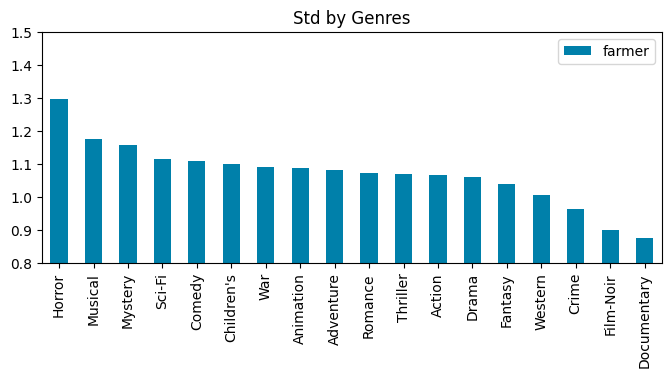

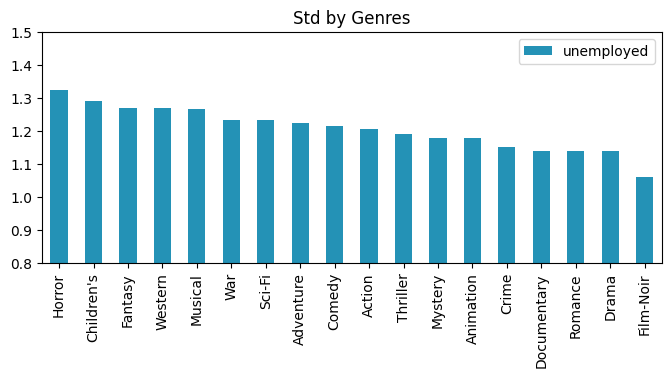

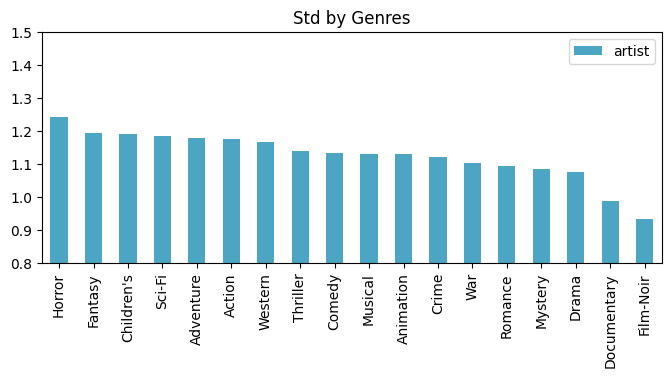

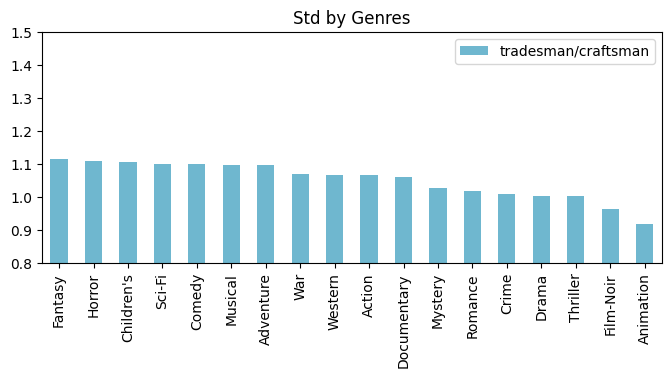

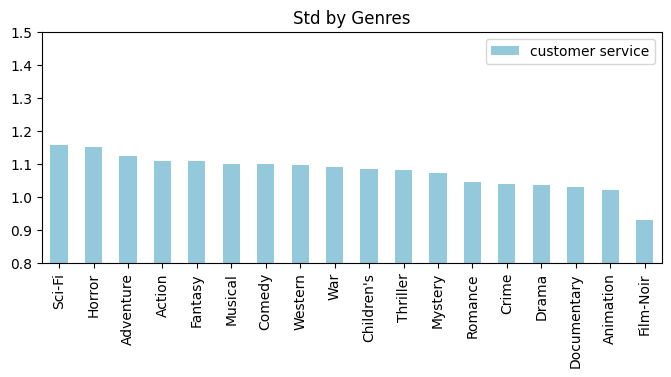

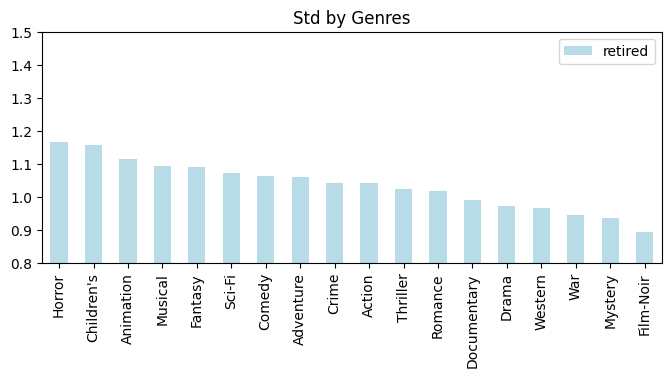

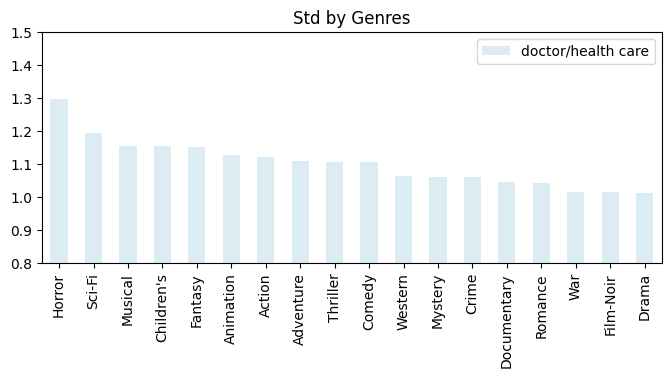

In [22]:
# 将每种职业对每类电影评分的标准差从大到小排序后展示
cnt = 1
for (occupation, color) in zip(occupations, colors):
    tmp = df_2.sort_values(by=(occupation, 'std'), inplace=False, ascending=False)
    tmp.plot.bar(y=(occupation, 'std'), color=color, figsize=(8, 3))
    plt.legend([occupation])
    plt.ylim([0.8, 1.5])
    plt.title('Std by Genres')
    plt.savefig(f'./figures/2_{cnt}_stds by genres.png')
    cnt += 1

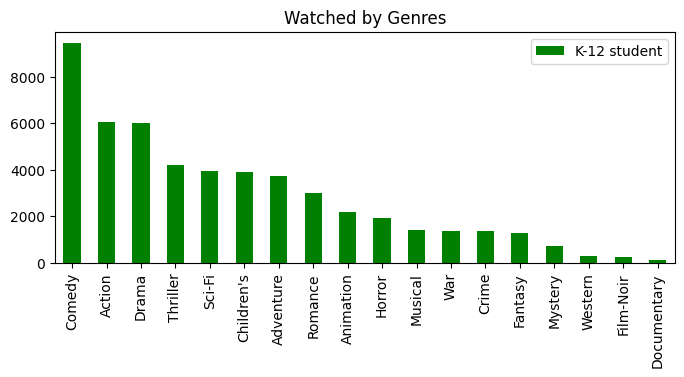

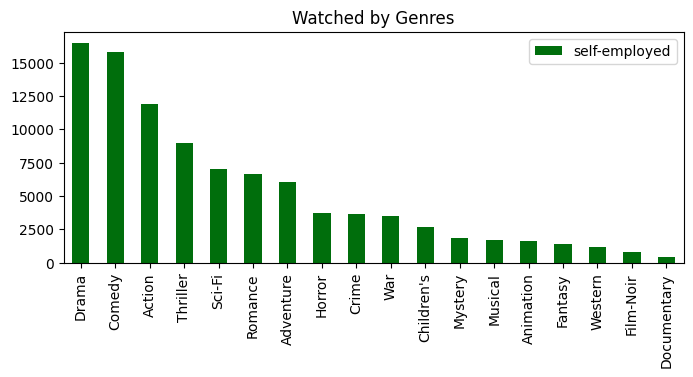

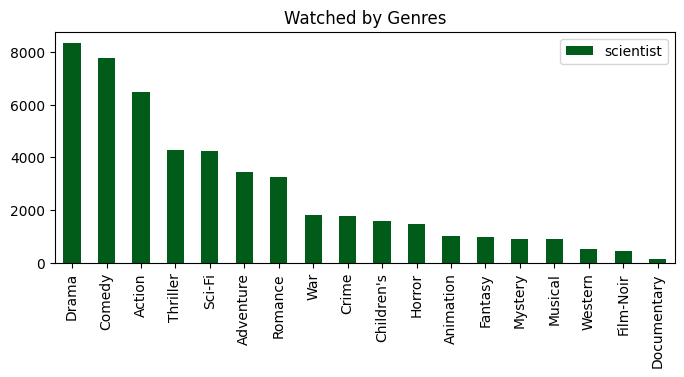

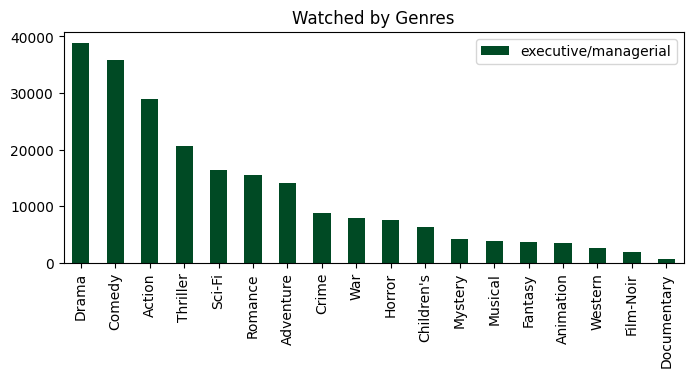

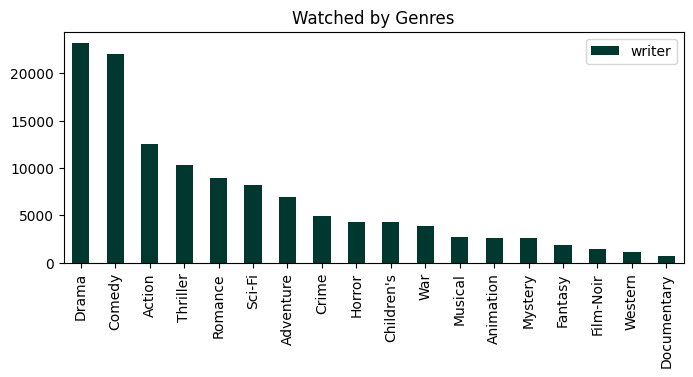

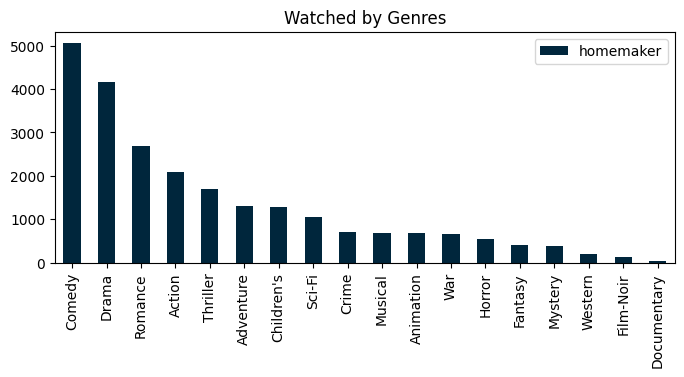

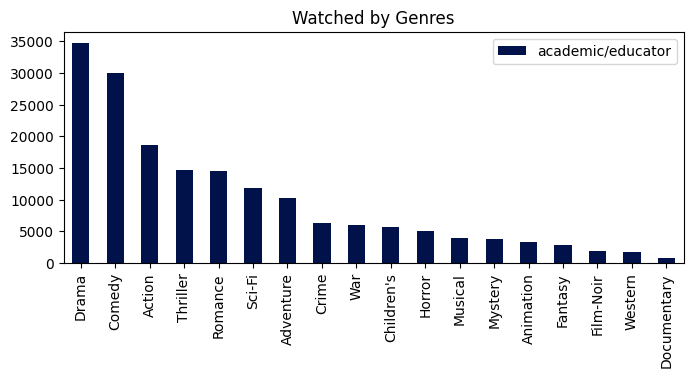

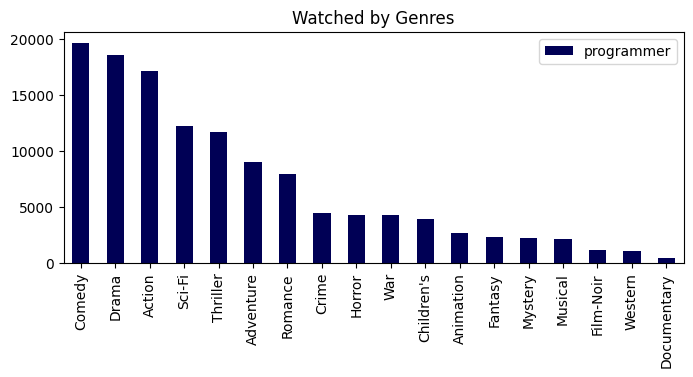

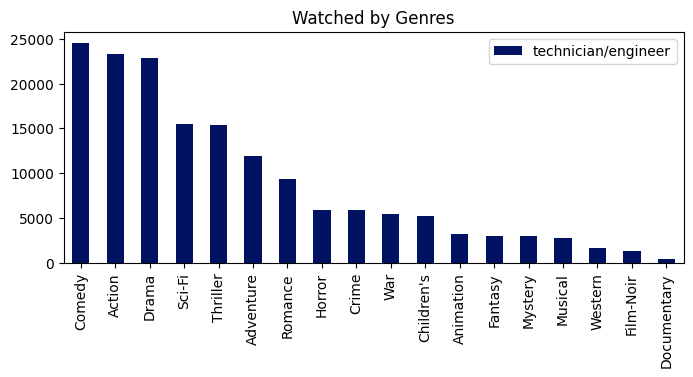

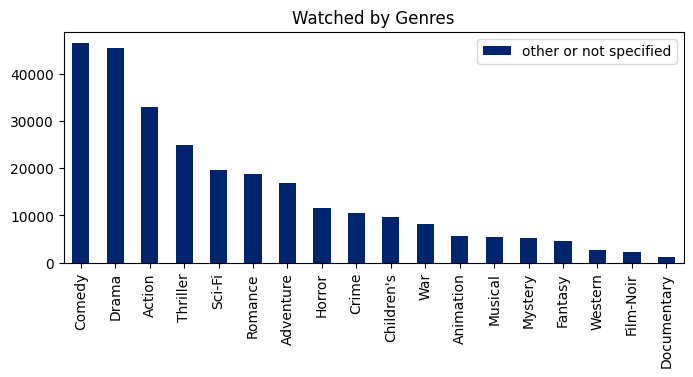

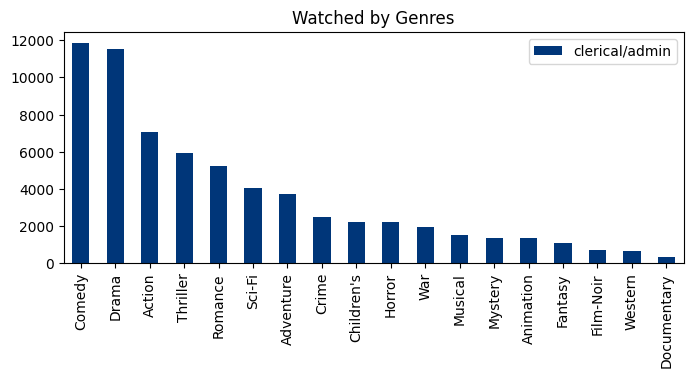

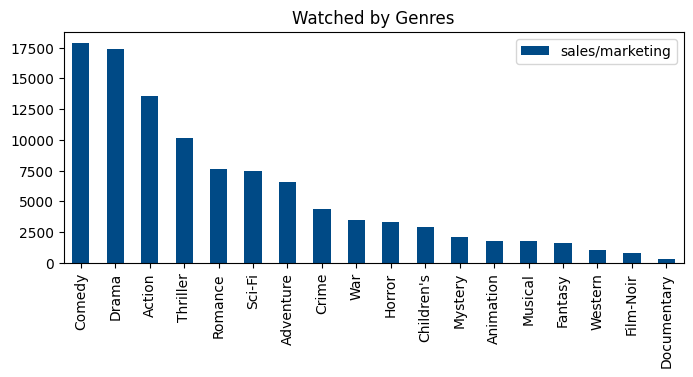

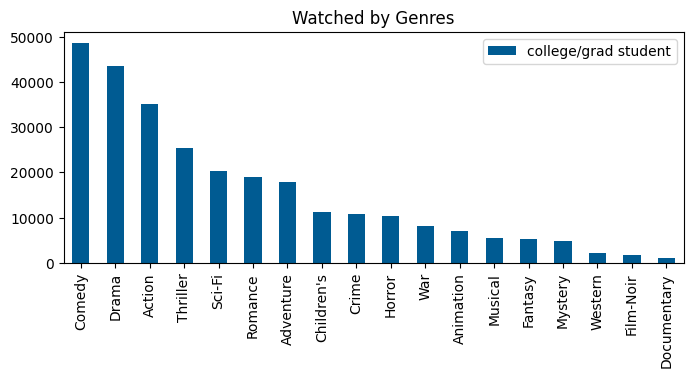

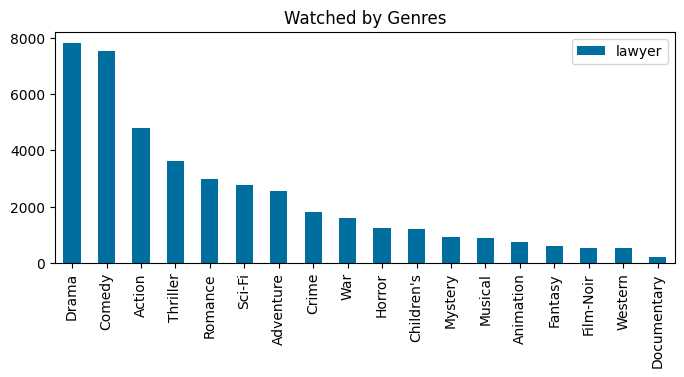

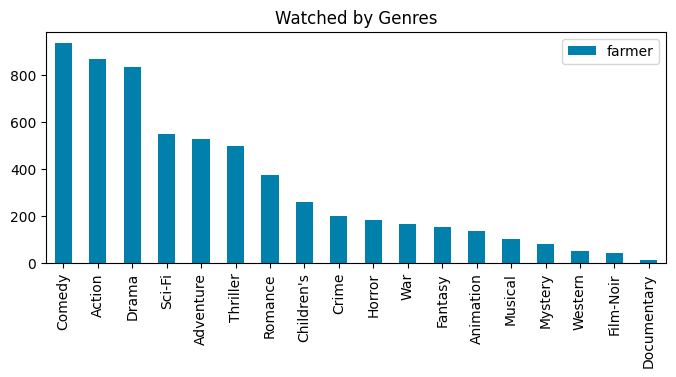

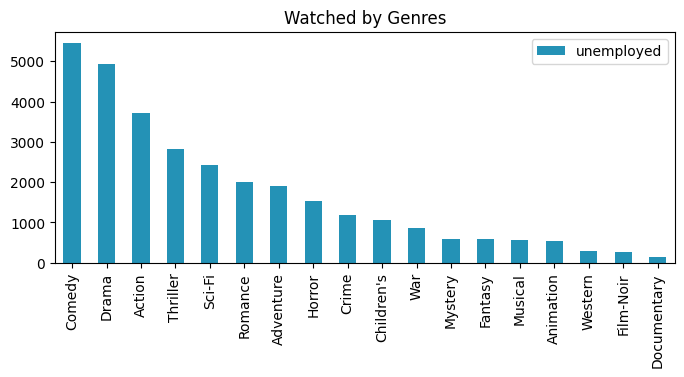

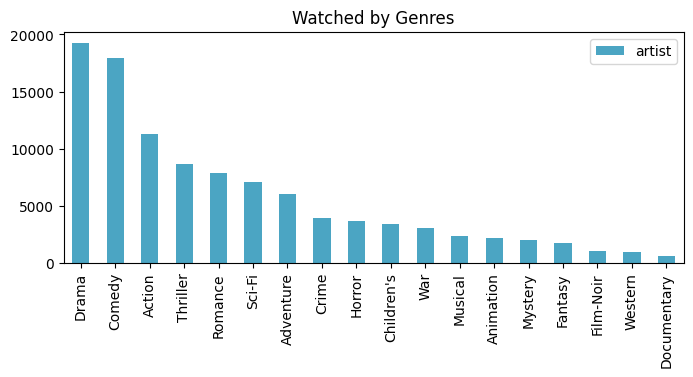

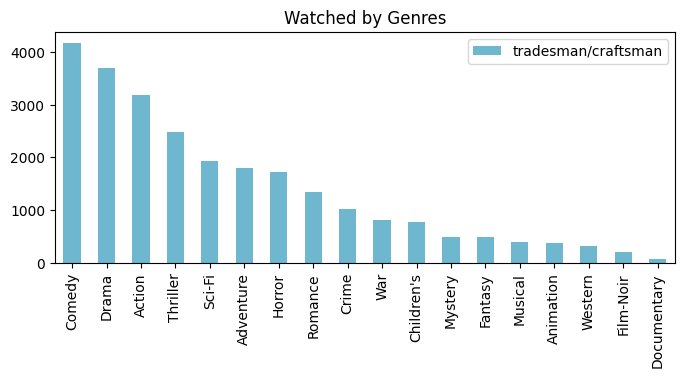

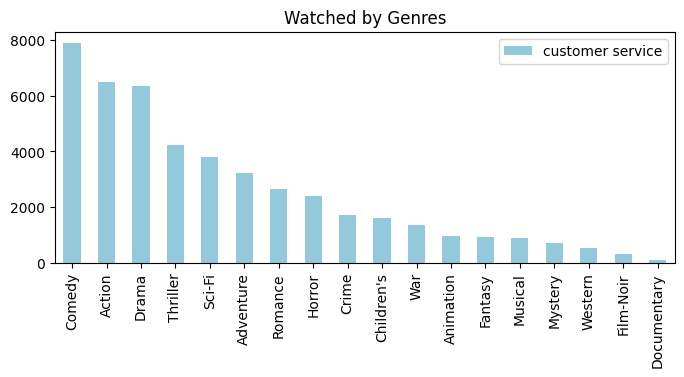

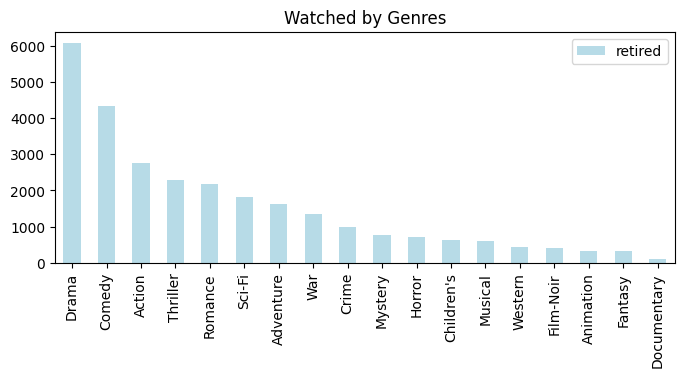

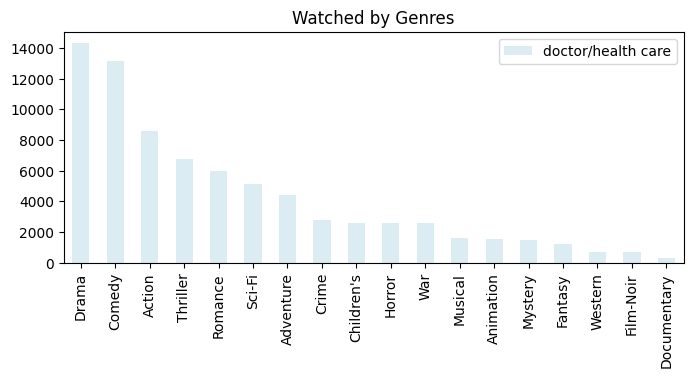

In [23]:
# 将每种职业对每类电影的观看人次（评分数量）从大到小排序后展示
cnt = 1
for (occupation, color) in zip(occupations, colors):
    tmp = df_2.sort_values(by=(occupation, 'count'), inplace=False, ascending=False)
    tmp.plot.bar(y=(occupation, 'count'), color=color, figsize=(8, 3))
    plt.legend([occupation])
    plt.title('Watched by Genres')
    plt.savefig(f'./figures/3_{cnt}_counts by genres.png')
    cnt += 1

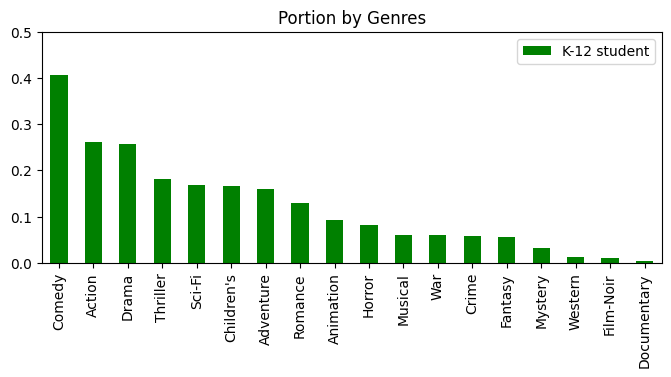

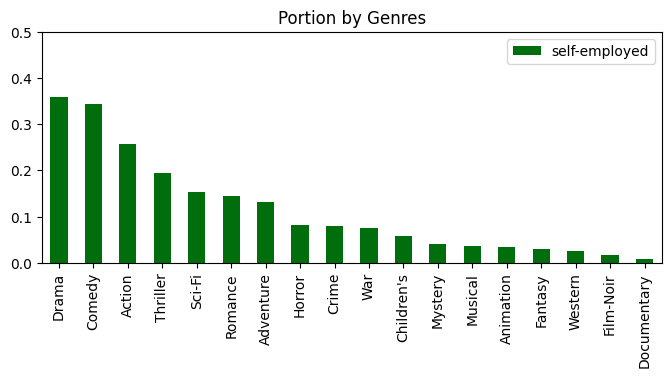

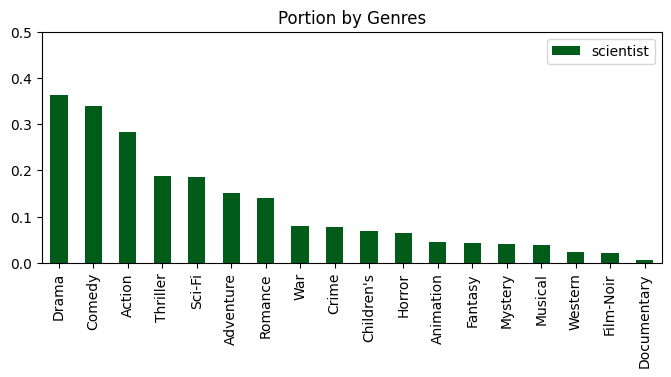

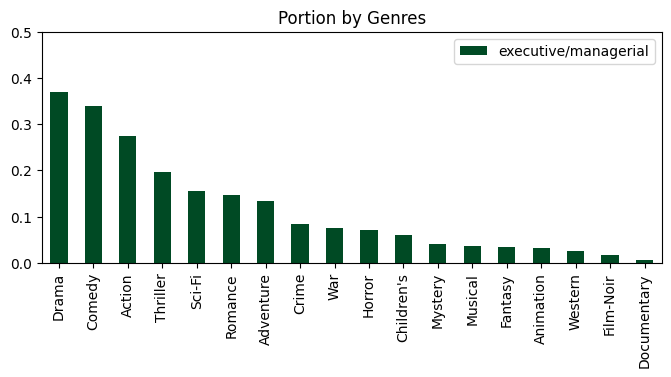

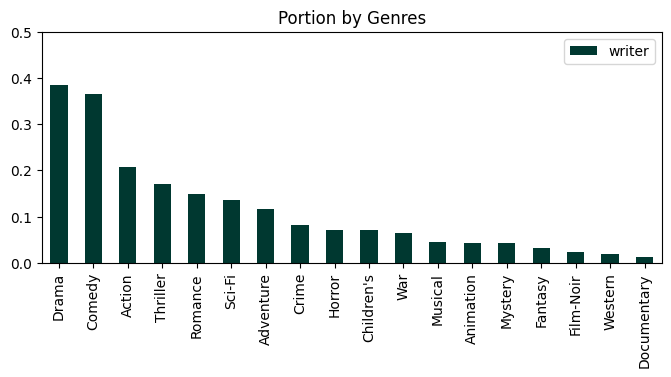

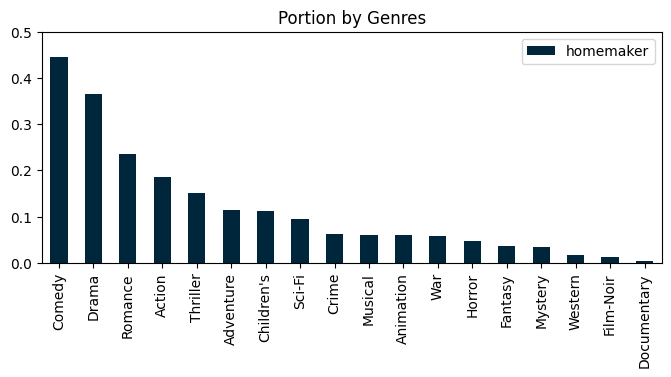

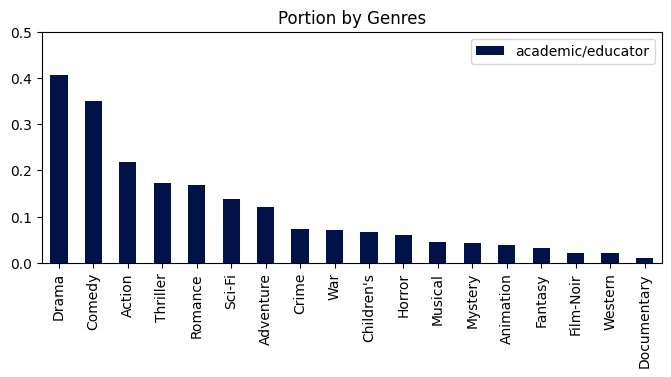

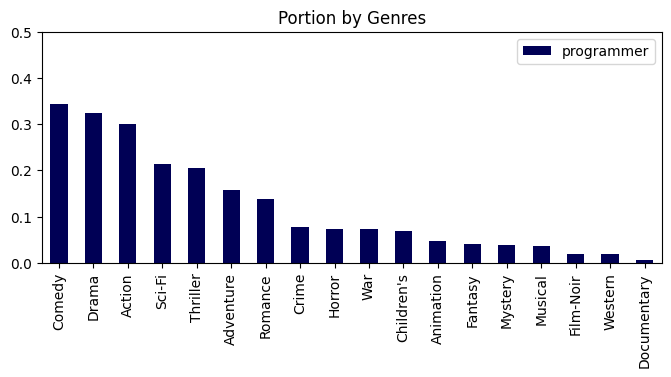

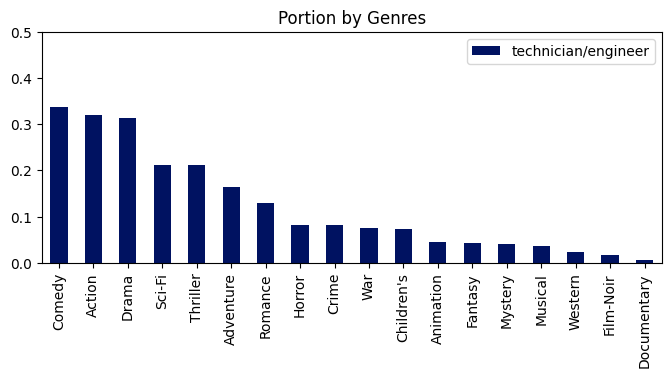

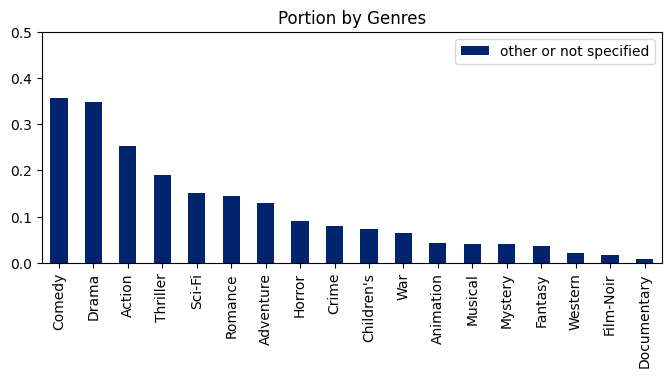

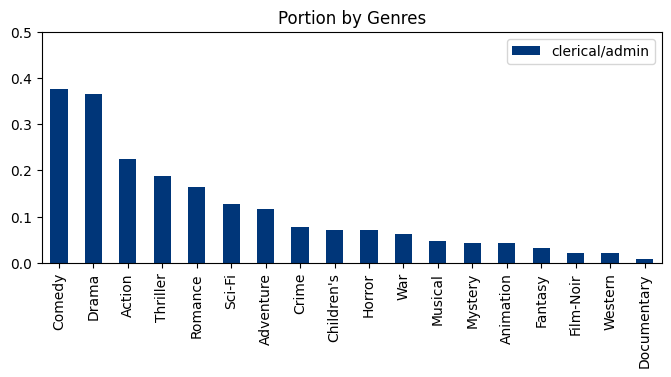

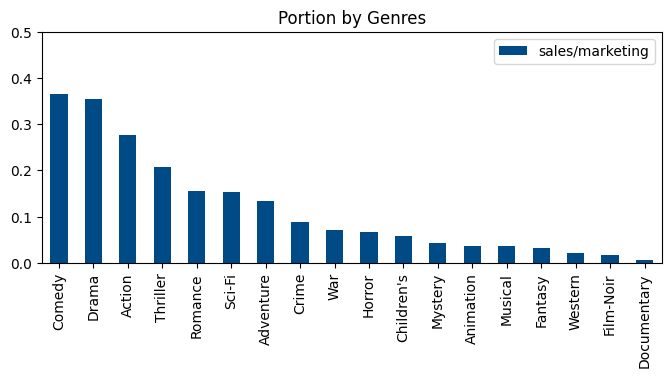

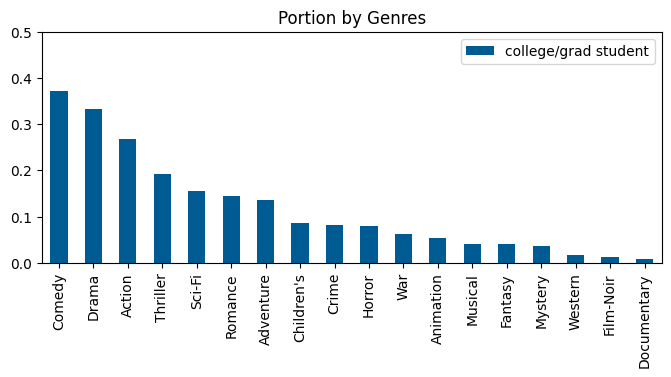

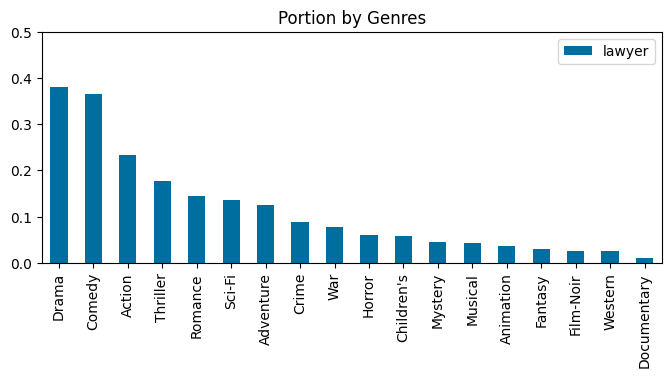

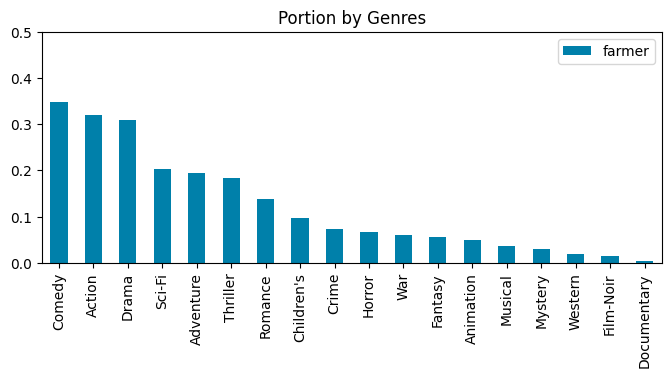

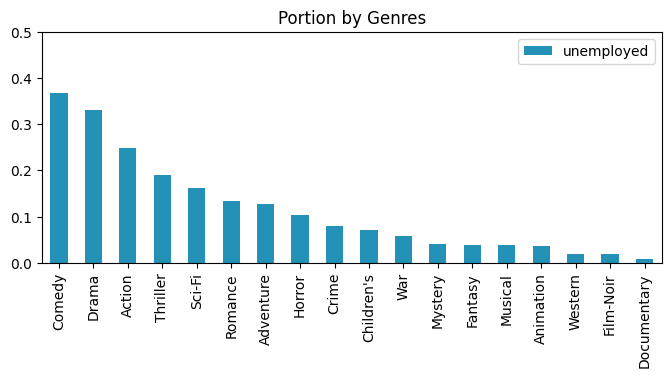

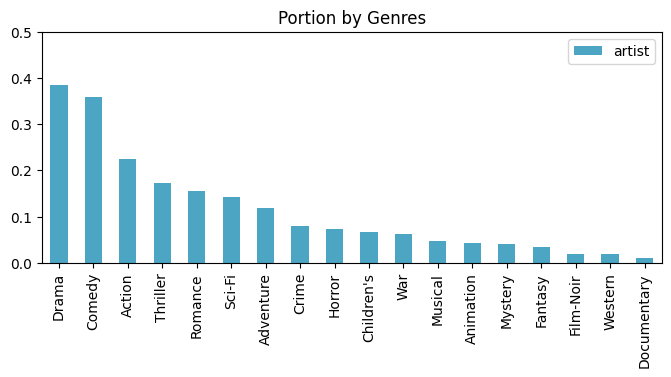

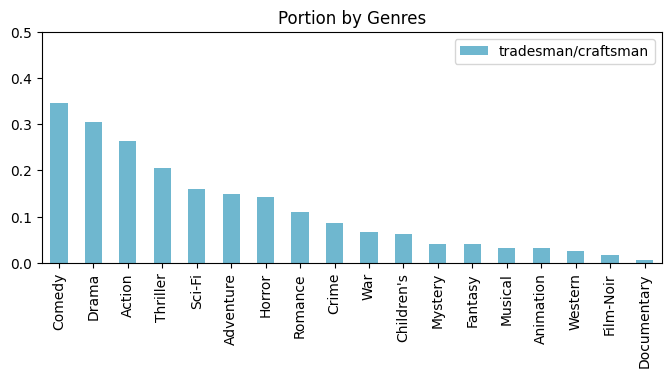

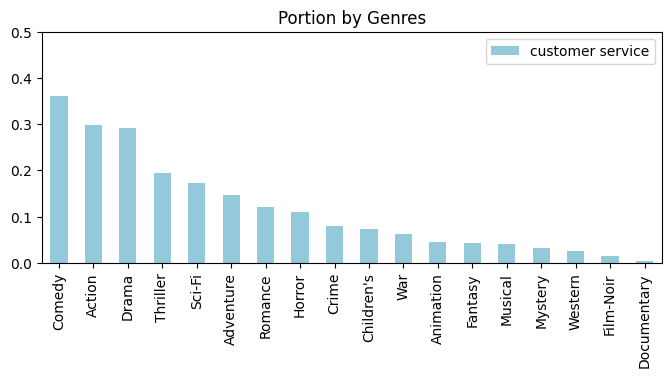

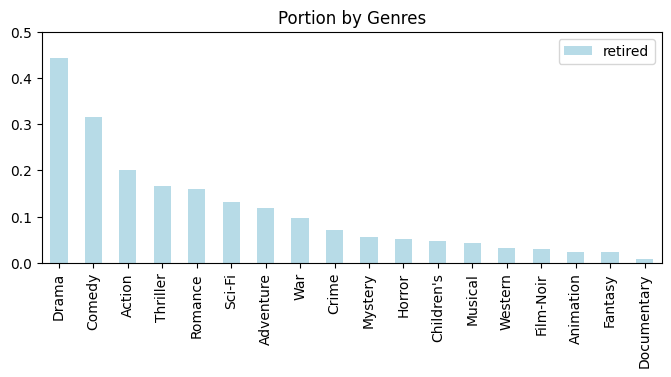

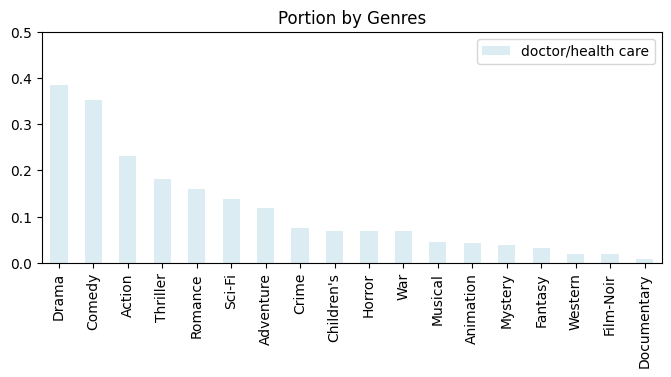

In [24]:
# 将每种职业对每类电影的评分数量在该职业总评分数量中的比例从大到小排序后展示(注意一个电影可以属于多个类，因此总和>1)
cnt = 1
for occupation, color in zip(occupations, colors):
    tmp = df_2.sort_values(by=(occupation, 'portion'), inplace=False, ascending=False)
    tmp.plot.bar(y=(occupation, 'portion'),figsize=(8, 3),color=color)
    plt.title('Portion by Genres')
    plt.legend([occupation])
    plt.ylim(0, 0.5)
    savefig_title = f"./figures/4_{cnt}_portions by genres.png"
    plt.savefig(savefig_title)
    cnt += 1

## 二、用户对电影的打分预测

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from catboost import Pool, CatBoostRegressor
from scipy.sparse import hstack
from scipy.sparse import csr_matrix


In [26]:
# 构建特征向量所需的数据
user_movie = pd.merge(users, ratings, on='user_id', how='inner')
user_movie_info = pd.merge(user_movie, movies_info, on='movie_id', how='inner')
user_movie_info = user_movie_info.set_index('user_id')
print('user_movie_info:')
user_movie_info.head()

user_movie_info:


,gender,zipcode,age_desc,occ_desc,movie_id,rating,timestamp,name,genre,release_time,intro,directors,stars
user_id,,,,,,,,,,,,,
1,F,48067,Under 18,K-12 student,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,19 November 1975 (USA),A criminal pleads insanity and is admitted to ...,Milos Forman,Jack Nicholson|Louise Fletcher|Will Sampson
1,F,48067,Under 18,K-12 student,661,3,978302109,James and the Giant Peach (1996),Animation|Adventure|Family,12 April 1996 (USA),"An orphan, who lives with his two cruel aunts,...",Henry Selick,Paul Terry|Joanna Lumley|Pete Postlethwaite
1,F,48067,Under 18,K-12 student,914,3,978301968,My Fair Lady (1964),Drama|Family|Musical,25 December 1964 (USA),Snobbish phonetics Professor Henry Higgins agr...,George Cukor,Audrey Hepburn|Rex Harrison|Stanley Holloway
1,F,48067,Under 18,K-12 student,3408,4,978300275,Erin Brockovich (2000),Biography|Drama,17 March 2000 (USA),An unemployed single mother becomes a legal as...,Steven Soderbergh,Julia Roberts|Albert Finney|David Brisbin
1,F,48067,Under 18,K-12 student,2355,5,978824291,A Bug's Life (1998),Animation|Adventure|Comedy,25 November 1998 (USA),"A misfit ant, looking for ""warriors"" to save h...",John Lasseter|Andrew Stanton,Kevin Spacey|Dave Foley|Julia Louis-Dreyfus


In [27]:
# 划分训练集和测试集
train, test = train_test_split(user_movie_info, test_size=0.2, random_state=42)
y_train = train['rating']
y_test = test['rating']
train = train.reset_index()
train.head()

,user_id,gender,zipcode,age_desc,occ_desc,movie_id,rating,timestamp,name,genre,release_time,intro,directors,stars
0,2116,M,49546,18-24,college/grad student,3809,3,974649905,What About Bob? (1991),Comedy,17 May 1991 (USA),A successful psychotherapist loses his mind af...,Frank Oz,Bill Murray|Richard Dreyfuss|Julie Hagerty
1,2458,M,85040,25-34,executive/managerial,608,1,974176907,Fargo (1996),Crime|Drama|Thriller,5 April 1996 (USA),Jerry Lundegaard's inept crime falls apart due...,Joel Coen|Ethan Coen,William H. Macy|Frances McDormand|Steve Buscemi
2,752,F,97401,25-34,clerical/admin,1034,4,976223846,Freeway (1996),Comedy|Crime|Drama,3 September 1997 (France),"A twisted take on ""Little Red Riding Hood"", wi...",Matthew Bright,Reese Witherspoon|Kiefer Sutherland|Bokeem Woo...
3,3871,M,64468,18-24,college/grad student,231,5,965844557,Dumb and Dumber (1994),Comedy,16 December 1994 (USA),After a woman leaves a briefcase at the airpor...,Peter Farrelly|Bobby Farrelly,Jim Carrey|Jeff Daniels|Lauren Holly
4,5153,M,60046,25-34,executive/managerial,2470,3,961968903,'Crocodile' Dundee (1986),Action|Adventure|Comedy,24 April 1986 (Australia),An American reporter goes to the Australian ou...,Peter Faiman,Paul Hogan|Linda Kozlowski|John Meillon


In [28]:
# 统计每个电影的类型
movie_genre = movies
movie_genre = movie_genre.drop(['title', 'genres'], axis=1)
train = pd.merge(train, movie_genre, on='movie_id', how='inner')
print('train:')
train.head()

train:


,user_id,gender,zipcode,age_desc,occ_desc,movie_id,rating,timestamp,name,genre,...,Sci-Fi,Fantasy,Documentary,Film-Noir,Children's,Romance,Mystery,Western,Musical,Adventure
0,2116,M,49546,18-24,college/grad student,3809,3,974649905,What About Bob? (1991),Comedy,...,0,0,0,0,0,0,0,0,0,0
1,2458,M,85040,25-34,executive/managerial,608,1,974176907,Fargo (1996),Crime|Drama|Thriller,...,0,0,0,0,0,0,0,0,0,0
2,752,F,97401,25-34,clerical/admin,1034,4,976223846,Freeway (1996),Comedy|Crime|Drama,...,0,0,0,0,0,0,0,0,0,0
3,3871,M,64468,18-24,college/grad student,231,5,965844557,Dumb and Dumber (1994),Comedy,...,0,0,0,0,0,0,0,0,0,0
4,5153,M,60046,25-34,executive/managerial,2470,3,961968903,'Crocodile' Dundee (1986),Action|Adventure|Comedy,...,0,0,0,0,0,0,0,0,0,1


In [29]:
# 求训练集中每一种职业对每一类电影的平均评分
column = []
for occupation in occupations:
    column.append(occupation)
avg_rating_record = pd.DataFrame(np.zeros((len(genre_list), len(column))), index=genre_list, columns=[column])

for occupation in occupations:
    train_occupation = train[train['occ_desc'] == occupation]
    # display(train_occupation.head())
    for genre in genre_list:
        tmp = train_occupation[train_occupation[genre]==1]
        avg_rating_record.loc[genre, occupation] = tmp['rating'].mean()
avg_rating_record = avg_rating_record.T
print('avg_rating_record:')
avg_rating_record.head()

avg_rating_record:


,Horror,War,Thriller,Animation,Action,Drama,Comedy,Crime,Sci-Fi,Fantasy,Documentary,Film-Noir,Children's,Romance,Mystery,Western,Musical,Adventure
K-12 student,3.252027,3.881810,3.557238,3.477472,3.500000,3.801501,3.502276,3.695735,3.449714,3.310958,3.842857,4.217877,3.235062,3.619570,3.613475,3.571429,3.579710,3.437500
self-employed,3.287132,3.926883,3.562544,3.707355,3.506300,3.804676,3.513744,3.740728,3.492871,3.472022,4.006192,4.101208,3.446998,3.615018,3.691525,3.620614,3.699193,3.504893
scientist,3.347009,3.948143,3.658345,3.812958,3.559869,3.843655,3.687173,3.808571,3.539485,3.557125,4.040650,4.191549,3.592116,3.685178,3.778677,3.819951,3.784203,3.573818
executive/managerial,3.244391,3.918745,3.624086,3.719356,3.567344,3.772326,3.524235,3.731245,3.505547,3.471284,3.940154,4.021132,3.451886,3.619079,3.665977,3.619205,3.681097,3.508833
writer,3.198243,3.780372,3.477120,3.689622,3.334652,3.670800,3.426184,3.648732,3.384485,3.330458,4.014679,4.120000,3.359557,3.483240,3.624260,3.647715,3.675991,3.346957


In [30]:
# 根据训练集的avg_rating_record构建训练集的用户偏好特征
train_preference_features = []
for i in range(len(train)):
    train_preference_features.append(avg_rating_record.loc[train.iloc[i]['occ_desc'], :].values)
train_preference_features = np.array(train_preference_features).reshape(len(train), -1)

In [31]:
train_preference_features.shape

(787156, 18)

In [32]:
# 去掉训练集和测试集中的标签
train = train.drop(['rating'], axis=1)
test = test.drop(['rating'], axis=1)
train = train.fillna('') # 有一个movie的条目是空的
test = test.fillna('')

In [33]:
# 构建用户信息的one-hot特征
encoder = OneHotEncoder(sparse_output=False)
train_user_features = encoder.fit_transform(train[['gender', 'age_desc', 'occ_desc']])
train_user_features = pd.DataFrame(train_user_features, columns=encoder.get_feature_names_out(['gender', 'age_desc', 'occ_desc']))
train_user_features.head()

,gender_F,gender_M,age_desc_18-24,age_desc_25-34,age_desc_35-44,age_desc_45-49,age_desc_50-55,age_desc_56+,age_desc_Under 18,occ_desc_K-12 student,...,occ_desc_other or not specified,occ_desc_programmer,occ_desc_retired,occ_desc_sales/marketing,occ_desc_scientist,occ_desc_self-employed,occ_desc_technician/engineer,occ_desc_tradesman/craftsman,occ_desc_unemployed,occ_desc_writer
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# 构建电影类别的one-hot特征
train_genre_features = train.iloc[:, -18:]
train_genre_features.head()

,Horror,War,Thriller,Animation,Action,Drama,Comedy,Crime,Sci-Fi,Fantasy,Documentary,Film-Noir,Children's,Romance,Mystery,Western,Musical,Adventure
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1


In [35]:
# 构建电影intro的特征
vectorizer1 = TfidfVectorizer(stop_words='english')
sparse_train_intro_features= vectorizer1.fit_transform(train['intro'])

In [36]:
# 构建电影title的特征
vectorizer2 = TfidfVectorizer(stop_words='english')
sparse_train_title_features= vectorizer2.fit_transform(train['name'].apply(lambda x: x[:-8]))

In [37]:
# 将构建的所有特征连接起来得到最终的特征向量
sparse_train_user_features = csr_matrix(train_user_features)
sparse_train_genre_features = csr_matrix(train_genre_features)
sparse_train_preference_features = csr_matrix(train_preference_features)
train_final_features = hstack([sparse_train_user_features, sparse_train_genre_features, train_preference_features, sparse_train_intro_features, sparse_train_title_features])

In [38]:
# 对测试集进行同样的处理
test_preference_features = []
for i in range(len(test)):
    test_preference_features.append(avg_rating_record.loc[test.iloc[i]['occ_desc'], :].values) # 注意此处使用的仍是从训练集统计得到的数据
test_preference_features = np.array(test_preference_features).reshape(len(test), -1)
test_user_features = encoder.transform(test[['gender', 'age_desc', 'occ_desc']])
test_user_features = pd.DataFrame(test_user_features, columns=encoder.get_feature_names_out(['gender', 'age_desc', 'occ_desc']))
test = pd.merge(test, movie_genre, on='movie_id', how='inner')
test_genre_features = test.iloc[:, -18:]
sparse_test_intro_features = vectorizer1.transform(test['intro'])
sparse_test_title_features = vectorizer2.transform(test['name'].apply(lambda x: x[:-8]))

In [39]:
sparse_test_user_features = csr_matrix(test_user_features)
sparse_test_genre_features = csr_matrix(test_genre_features)
sparse_test_preference_features = csr_matrix(test_preference_features)

test_final_features = hstack([sparse_test_user_features, sparse_test_genre_features, sparse_test_preference_features, sparse_test_intro_features, sparse_test_title_features])

In [40]:
catboost_model = CatBoostRegressor(iterations=2000, learning_rate=0.2)
data_pool = Pool(train_final_features, y_train)
catboost_model.fit(data_pool)

0:	learn: 1.1082371	total: 146ms	remaining: 4m 52s
1:	learn: 1.1030331	total: 208ms	remaining: 3m 27s
2:	learn: 1.0986225	total: 293ms	remaining: 3m 15s
3:	learn: 1.0953761	total: 380ms	remaining: 3m 9s
4:	learn: 1.0922174	total: 479ms	remaining: 3m 10s
5:	learn: 1.0898078	total: 535ms	remaining: 2m 57s
6:	learn: 1.0878255	total: 586ms	remaining: 2m 46s
7:	learn: 1.0860519	total: 644ms	remaining: 2m 40s
8:	learn: 1.0840564	total: 703ms	remaining: 2m 35s
9:	learn: 1.0826730	total: 756ms	remaining: 2m 30s
10:	learn: 1.0810478	total: 814ms	remaining: 2m 27s
11:	learn: 1.0796746	total: 871ms	remaining: 2m 24s
12:	learn: 1.0785223	total: 924ms	remaining: 2m 21s
13:	learn: 1.0772672	total: 973ms	remaining: 2m 18s
14:	learn: 1.0761675	total: 1.04s	remaining: 2m 17s
15:	learn: 1.0751804	total: 1.09s	remaining: 2m 15s
16:	learn: 1.0736173	total: 1.15s	remaining: 2m 14s
17:	learn: 1.0726313	total: 1.2s	remaining: 2m 11s
18:	learn: 1.0713217	total: 1.25s	remaining: 2m 10s
19:	learn: 1.0703909	tot

In [41]:
# 评估模型
y_pred = catboost_model.predict(test_final_features)
mse = mean_squared_error(y_test, y_pred)
print("The mean squared error (MSE) on test set: {}".format(mse))

The mean squared error (MSE) on test set: 0.9371693010099992


## 三、电影海报聚类分析

In [42]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import torch
from img2vec_pytorch import Img2Vec

# 文件夹路径
folder_path = "./poster"

# 初始化特征列表
features = []
kmeans_features = []

img2vec_model = Img2Vec()
# 遍历文件夹中的每个海报图像
for filename in os.listdir(folder_path):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        # 读取图像
        image_path = os.path.join(folder_path, filename)
        image = cv2.imread(image_path)
        image = Image.open(image_path)
        if image.mode != 'RGB':
            image = image.convert('RGB')

        # 提取颜色直方图和灰度直方图特征，在无监督聚类中使用（题目有要求）
        rgb_image = np.array(image)
        gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)

        # 计算彩色直方图
        color_hist = cv2.calcHist([rgb_image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
        color_hist = cv2.normalize(color_hist, color_hist).flatten()

        # 计算灰度直方图
        gray_hist = cv2.calcHist([gray_image], [0], None, [256], [0, 256])
        gray_hist = cv2.normalize(gray_hist, gray_hist).flatten()

        # 连接两个直方图并加入kmeans_features中
        kmeans_features.append(np.hstack((color_hist, gray_hist)))
        
        # 利用img2vec提取特征，在有监督聚类中使用
        vector = img2vec_model.get_vec(image)
        feature_vector = vector

        # 添加图像文件前缀（电影ID）和特征向量到特征列表中
        features.append([filename.split('.')[0], feature_vector])

# 将特征列表转换为DataFrame
columns = ['movie_id', 'features']
df = pd.DataFrame(features, columns=columns)

# 输出带有电影ID和特征向量的DataFrame
print("DataFrame with Movie ID and Features:")
print(df.head())

DataFrame with Movie ID and Features:
  movie_id                                           features
0       63  [0.03181022, 0.4679307, 0.8066899, 0.4369812, ...
1      823  [0.54533017, 2.6612434, 0.052591085, 0.4809450...
2     3578  [0.04319999, 0.386104, 0.8370001, 0.0, 0.74675...
3     2100  [0.10941267, 2.0392597, 0.9851427, 0.60722953,...
4     1409  [0.17741236, 1.0916624, 0.19859573, 0.00152080...


### 无监督聚类(主要依据色彩与灰度值)

In [43]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


pca = PCA(n_components=50, random_state=42)
pca_features = pca.fit_transform(np.array(kmeans_features))

kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(pca_features)

df

,movie_id,features,kmeans_cluster
0,63,"[0.03181022, 0.4679307, 0.8066899, 0.4369812, ...",1
1,823,"[0.54533017, 2.6612434, 0.052591085, 0.4809450...",4
2,3578,"[0.04319999, 0.386104, 0.8370001, 0.0, 0.74675...",0
3,2100,"[0.10941267, 2.0392597, 0.9851427, 0.60722953,...",1
4,1409,"[0.17741236, 1.0916624, 0.19859573, 0.00152080...",3
...,...,...,...
2933,3213,"[0.75683874, 1.126783, 4.2811904, 0.48052168, ...",3
2934,190,"[0.104476385, 1.7208096, 0.23858008, 0.5907070...",1
2935,184,"[1.6203073, 2.804204, 0.45903713, 0.41096118, ...",3
2936,2119,"[0.46478897, 0.6600336, 0.2783797, 0.24570668,...",3


In [44]:
representative_images = []
for i in range(5):
    tmp = df[df['kmeans_cluster']==i]
    representative_images.append(tmp.index[:5].values)

representative_images = np.array(representative_images, dtype=int)
representative_images

array([[ 2,  7, 15, 18, 20],
       [ 0,  3,  6,  9, 10],
       [11, 12, 14, 28, 35],
       [ 4,  8, 19, 23, 26],
       [ 1,  5, 16, 17, 33]])

### 无监督聚类结果的可视化

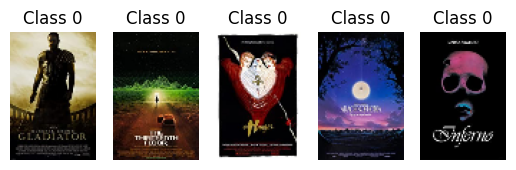

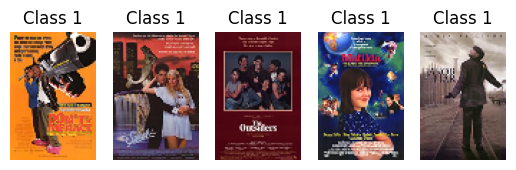

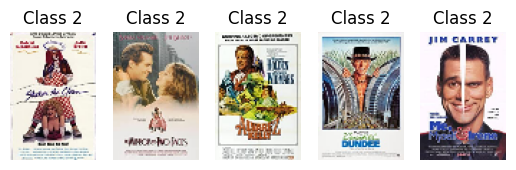

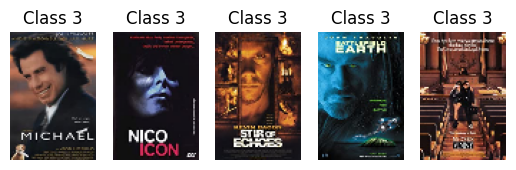

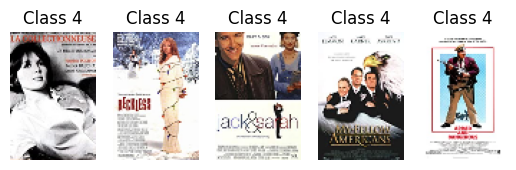

In [45]:
import matplotlib.pyplot as plt
# 打印每个类别的代表性图像
for i, indices in enumerate(representative_images):
    # 设置图像的大小
    for j, index in enumerate(indices):
        # 读取代表性图像
        representative_image_path = os.path.join(folder_path, os.listdir(folder_path)[index])
        representative_image = cv2.imread(representative_image_path)
        representative_image = cv2.resize(representative_image, (60, 90))
        # 绘制图像
        plt.subplot(1, 5, j+1)
        plt.imshow(cv2.cvtColor(representative_image, cv2.COLOR_BGR2RGB))
        plt.title("Class {}".format(i))
        plt.axis("off")

    plt.show()


### 有监督聚类

In [46]:
import pandas as pd

# 读取CSV文件
movies_df = pd.read_csv("./movies.csv")

# 提取genre信息
genres = movies_df['genres']
# 初始化genre的字典
genre_dict = {}

# 遍历每个电影的genre信息
for genre_string in genres:
    # 将genre字符串按照"|"分割成列表
    genre_list = genre_string.split("|")
    # 遍历列表中的每个genre
    for genre in genre_list:
        # 将genre添加到字典中，如果已存在则不重复添加
        if genre not in genre_dict:
            genre_dict[genre] = len(genre_dict)

# 输出genre字典
print("Genre Dictionary:")
print(genre_dict)

Genre Dictionary:
{'Animation': 0, "Children's": 1, 'Comedy': 2, 'Adventure': 3, 'Fantasy': 4, 'Romance': 5, 'Drama': 6, 'Action': 7, 'Crime': 8, 'Thriller': 9, 'Horror': 10, 'Sci-Fi': 11, 'Documentary': 12, 'War': 13, 'Musical': 14, 'Mystery': 15, 'Film-Noir': 16, 'Western': 17}


In [47]:
# 将genre信息转换为向量形式
genre_vectors = []

# 遍历每个电影的genre信息
for genre_string in genres:
    # 将genre字符串按照"|"分割成列表
    genre_list = genre_string.split("|")
    # 初始化genre向量
    genre_vector = [0] * len(genre_dict)
    # 根据genre列表设置向量中对应的位置为1
    for genre in genre_list:
        genre_vector[genre_dict[genre]] = 1
    # 将genre向量添加到列表中
    genre_vectors.append(genre_vector)

# 将genre向量转换为列表
genre_lists = [list(genre_vector) for genre_vector in genre_vectors]

# 将genre列表添加到movies_df中
movies_df['genre_vector'] = genre_lists

# 输出带有genre向量的movies_df
print("Movies DataFrame with Genre Vector:")
display(movies_df.head())

Movies DataFrame with Genre Vector:


,Unnamed: 0,movie_id,title,genres,genre_vector
0,0,1,Toy Story (1995),Animation|Children's|Comedy,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,2,Jumanji (1995),Adventure|Children's|Fantasy,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,3,Grumpier Old Men (1995),Comedy|Romance,"[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,4,Waiting to Exhale (1995),Comedy|Drama,"[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,5,Father of the Bride Part II (1995),Comedy,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [48]:
# 将电影ID列转换为整数类型
movies_df['movie_id'] = movies_df['movie_id'].astype(int)
df['movie_id'] = df['movie_id'].astype(int)

In [49]:
# 使用 merge 方法按照 movie_id 合并两个 DataFrame
# Reading movies info file
movies_info = pd.read_csv('./info.csv',  encoding='latin-1', usecols=['id', 'name', 'genre','intro','directors','starts', 'release_time'])
movies_info.rename(columns ={ 'id':'movie_id', 'starts': 'stars'}, inplace = True)
merged_df = pd.merge(movies_df, df, on='movie_id', how='inner')
merged_df = pd.merge(merged_df, movies_info, on='movie_id', how='inner')
merged_df = merged_df.drop(['Unnamed: 0', 'name', 'genre', 'release_time'], axis=1)

In [50]:
# 输出合并后的 DataFrame
print("Merged DataFrame:")
display(merged_df.head())

Merged DataFrame:


,movie_id,title,genres,genre_vector,features,kmeans_cluster,intro,directors,stars
0,1,Toy Story (1995),Animation|Children's|Comedy,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2273532, 1.1728467, 0.29160947, 3.7952757, ...",1,A cowboy doll is profoundly threatened and jea...,John Lasseter,Tom Hanks|Tim Allen|Don Rickles
1,2,Jumanji (1995),Adventure|Children's|Fantasy,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.823149, 0.40036517, 0.5189065, 0.16395436, ...",3,When two kids find and play a magical board ga...,Joe Johnston,Robin Williams|Kirsten Dunst|Bonnie Hunt
2,3,Grumpier Old Men (1995),Comedy|Romance,"[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0070503666, 0.7824923, 0.462313, 0.0, 0.418...",3,John and Max resolve to save their beloved bai...,Howard Deutch,Walter Matthau|Jack Lemmon|Ann-Margret
3,4,Waiting to Exhale (1995),Comedy|Drama,"[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.07367638, 0.3519281, 0.37811843, 0.3463346,...",2,"Based on Terry McMillan's novel, this film fol...",Forest Whitaker,Whitney Houston|Angela Bassett|Loretta Devine
4,5,Father of the Bride Part II (1995),Comedy,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.7759676, 1.6042546, 1.2051768, 0.038728412,...",0,George Banks must deal not only with the pregn...,Charles Shyer,Steve Martin|Diane Keaton|Martin Short


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from transformers import BertTokenizer, BertModel

In [52]:
# 加载预训练的tokenizer和模型
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

In [53]:
titles = merged_df['title'].apply(lambda x: x[:-7])
titles = titles.tolist()
# 编码文本
encoded_inputs = tokenizer(titles, padding=True, truncation=True, return_tensors="pt")
# 获取模型输出
with torch.no_grad():
    outputs = model(**encoded_inputs)
# 使用pooler_output作为特征
title_features = outputs.pooler_output

In [54]:
intros = merged_df['intro'].tolist()
# 编码文本
encoded_inputs = tokenizer(intros, padding=True, truncation=True, return_tensors="pt")
# 获取模型输出
with torch.no_grad():
    outputs = model(**encoded_inputs)
# 使用pooler_output作为特征
intro_features = outputs.pooler_output

In [55]:
# 计算每部电影的平均评分和评分数量
ratings = pd.read_csv('./ratings2.csv',  encoding='latin-1', usecols=['user_id', 'movie_id', 'rating', 'timestamp'])
movie_ratings = ratings.groupby('movie_id')['rating'].agg(['mean', 'std', 'count'])

# 将这些特征添加到电影数据中
merged_df = pd.merge(merged_df, movie_ratings, on='movie_id', how='left')

In [56]:
merged_df.head()

,movie_id,title,genres,genre_vector,features,kmeans_cluster,intro,directors,stars,mean,std,count
0,1,Toy Story (1995),Animation|Children's|Comedy,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2273532, 1.1728467, 0.29160947, 3.7952757, ...",1,A cowboy doll is profoundly threatened and jea...,John Lasseter,Tom Hanks|Tim Allen|Don Rickles,4.146846,0.852349,2077.0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,"[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.823149, 0.40036517, 0.5189065, 0.16395436, ...",3,When two kids find and play a magical board ga...,Joe Johnston,Robin Williams|Kirsten Dunst|Bonnie Hunt,3.201141,0.983172,701.0
2,3,Grumpier Old Men (1995),Comedy|Romance,"[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0070503666, 0.7824923, 0.462313, 0.0, 0.418...",3,John and Max resolve to save their beloved bai...,Howard Deutch,Walter Matthau|Jack Lemmon|Ann-Margret,3.016736,1.071712,478.0
3,4,Waiting to Exhale (1995),Comedy|Drama,"[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.07367638, 0.3519281, 0.37811843, 0.3463346,...",2,"Based on Terry McMillan's novel, this film fol...",Forest Whitaker,Whitney Houston|Angela Bassett|Loretta Devine,2.729412,1.013381,170.0
4,5,Father of the Bride Part II (1995),Comedy,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.7759676, 1.6042546, 1.2051768, 0.038728412,...",0,George Banks must deal not only with the pregn...,Charles Shyer,Steve Martin|Diane Keaton|Martin Short,3.006757,1.025086,296.0


In [57]:
rating_features = merged_df[['mean', 'std', 'count']].values

In [58]:
# 提取特征和标签
image_X = merged_df['features'].values.tolist()
intro_X = intro_features
title_X = title_features
rating_X = rating_features
y = np.array(merged_df['genre_vector'].tolist())

# 划分训练集和测试集，注意要使用相同的随机种子以保证划分一致
image_X_train, image_X_test, image_y_train, image_y_test = train_test_split(image_X, y, test_size=0.2, random_state=42)
intro_X_train, intro_X_test, intro_y_train, intro_y_test = train_test_split(intro_X, y, test_size=0.2, random_state=42)
title_X_train, title_X_test, title_y_train, title_y_test = train_test_split(title_X, y, test_size=0.2, random_state=42)
rating_X_train, rating_X_test, rating_y_train, rating_y_test = train_test_split(rating_X, y, test_size=0.2, random_state=42)

In [59]:
# 根据图像特征训练分类器
image_model = XGBClassifier(max_depth=2)
image_model.fit(image_X_train, image_y_train)
image_y_pred = image_model.predict_proba(image_X_test)

In [60]:
# 根据电影简介训练分类器
intro_model = XGBClassifier(max_depth=3)
intro_model.fit(intro_X_train, intro_y_train)
intro_y_pred = intro_model.predict_proba(intro_X_test)

In [61]:
# 根据电影名称训练分类器
title_model = XGBClassifier(max_depth=5)
title_model.fit(title_X_train, title_y_train)
title_y_pred = title_model.predict_proba(title_X_test)

In [62]:
# 根据用户评分情况训练分类器
rating_model = XGBClassifier(max_depth=4)
rating_model.fit(rating_X_train, rating_y_train)
rating_y_pred = rating_model.predict_proba(rating_X_test)

In [63]:
# 对预测结果进行加权，设定阈值得到输出
sum = 1.25 * intro_y_pred + 1 * image_y_pred + 0.5 * title_y_pred + 1.4 * rating_y_pred
maxi = 0
maxi_th = -1
for th in range(0, 5000):
    tmp = (sum > (th / 1000)).astype(int)
    if accuracy_score(image_y_test, tmp) > maxi:
        maxi = accuracy_score(image_y_test, tmp)
        maxi_th = th

y_pred = (sum > maxi_th / 1000).astype(int)

In [64]:
# 评估模型性能
accuracy = accuracy_score(image_y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(image_y_test, y_pred))

Accuracy: 0.23809523809523808
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.03      0.07        29
           1       1.00      0.08      0.15        51
           2       0.58      0.58      0.58       181
           3       0.67      0.04      0.08        49
           4       0.00      0.00      0.00         8
           5       1.00      0.06      0.12        77
           6       0.64      0.80      0.71       251
           7       0.84      0.22      0.35        96
           8       0.00      0.00      0.00        35
           9       0.57      0.05      0.10        73
          10       0.83      0.18      0.29        57
          11       1.00      0.23      0.37        44
          12       0.00      0.00      0.00        11
          13       1.00      0.04      0.07        26
          14       0.00      0.00      0.00        22
          15       0.00      0.00      0.00        18
          16       0.00     